<a href="https://colab.research.google.com/github/mariasagastume/dynamicattractor/blob/main/dynamic_attractor_network_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamic Attractor Network: Memory Formation, Reinforcement & Forgetting

*Computational-neuroscience seminar project -> reproduction and extension of Boscaglia et al. (2023).*

This notebook implements a **rate-based recurrent network of 100 neurons** that forms memory
*assemblies* through online Hebbian learning. Starting from a single-assembly baseline, we build
up to multi-assembly experiments that ask when two memories **fuse**, **stay separate**, or settle
into a **stable partial overlap** ("semantic bridge").

**Model ingredients** (all following the paper):

| Component | Role |
|---|---|
| Rate dynamics + sigmoid gain | Neuron activation (Eq. 1–3) |
| Neural adaptation (`tau_teta`, `D_teta`) | Neurons fatigue after sustained firing |
| Online Hebbian learning (`LR`, `tau_w`) | Co-active neurons wire together |
| Forgetting term (`beta`) | Unused connections decay |
| Gaussian background noise (`C_noise`) | Stochastic drive (Eq. 6) |
| Synaptic normalization — SW (`Factor_SW`) | Keeps incoming weights bounded (Eq. 9) |
| Divisive normalization — SR (`Factor_SR`) | Keeps overall activity bounded |

**Sources**
- Paper: Boscaglia et al., *PLOS Computational Biology* (2023) — https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011727
- Reference code: https://github.com/MartaBoscaglia/DynamicAttractorNetworkModel_2023
- This project's repo: https://github.com/mariasagastume/dynamicattractor

## How to run
1. **Open** any Jupyter environment with `numpy` + `matplotlib`.
2. Run the cells **top to bottom**. The **Setup → Base model** block must be run first: it defines
   the parameters, the core simulation loop, and the helper functions that every later week reuses.
3. Some full-length runs (Weeks 4–6) use large `total_time` values and take several minutes.
   Each has a small **sanity-check** run just before it; lower `total_time` for a faster preview.

## Contents
- **Setup & base model (Weeks 1–3):** parameters, core simulation loop, single-assembly formation and stability.
  - Week 2 milestone — weight-evolution figure
  - Week 3 milestone — stability / pass–fail check
- **Week 4:** frequency-dependent assembly growth.
- **Week 5:** memory competition (reinforcement & forgetting), then a two-phase formation → competition version.
- **Week 6:** overlapping memories and the functional / "semantic bridge" experiments (incl. staggered onsets).

> **Reproducibility.** `RANDOM_SEED = 42` is fixed in the parameter cell, so a top-to-bottom run
> reproduces the figures shown in the report/presentation. See `README.md` for the figure ↔ cell map.


## Setup 


Everything below defines the network. Run this whole block **first**: it sets the parameters,
builds the stimulation schedule, defines the helper functions and the core simulation loop, then
runs the single-assembly baseline and plots its firing rates and weight evolution.

*Baseline replication — cf. Boscaglia et al., Fig. 2.*


In [40]:


import os
import glob
import pickle
import zipfile
import numpy as np
import matplotlib.pyplot as plt

# Set the save path to a folder on your laptop
# The './' means "the current folder where this notebook is located"
BASE_DIR = './attractor_network_results'

# Physically create the folder at the chosen path.
# exist_ok=True prevents the code from crashing if the folder already exists.
os.makedirs(BASE_DIR, exist_ok=True)
print('Results folder:', BASE_DIR)


Results folder: ./attractor_network_results


In [ ]:
# Parameters
# Change these values here before running the simulation.

SAVING_RESULTS = True
CLEAN_OUTPUT_DIR = True
RANDOM_SEED = 42          # Set to None for a different random run each time
MEMORY_DTYPE = np.float32 # Use np.float64 for higher precision, but more RAM

# --- Network parameters ---
HowManyStimNeurons = 10  # neurons in a single memory assembly
N = 100                  # total number of neurons
dt = 0.1                 # time step for Euler integration
r_max = 1.0              # max firing rate 
r0 = 0.0                 # baseline firing rate (inactive neuron)
tau = 1.0                # how fast a neuron activates
h0 = 0.15                # threshold (for a neuron to start firing)
b = 100.0                # steepness of sigmoid (how abruptly a neuron turns on)

# ---- Synaptic weight bounds ----
Wmax = 3 / HowManyStimNeurons    # max limit for how strong a connection can get
Wmin = -0.5 / HowManyStimNeurons # min limit, allows for slight negative weights

# ---- Background noise ----
Noise_Factor_RATE = 0.2 / HowManyStimNeurons
# The coupling constant for the Gaussian noise, scaled by the time step (Equation 6 in the paper)
C_noise = np.sqrt(dt / tau) * Noise_Factor_RATE

SaturationWeights = True        # if true: enforces Wmin and Wmax
NoNegativeWeights = False       # if true: Wmin is 0 instead of -0.5
autoconnections = False         # if false: a neuron can't form a synaptic connection with itself

# For Colab testing, keep tmax moderate.
# Original paper-like runs can be much larger and may require too much RAM/time.
tmax = 60000 #milestone week 1
#tmax = 55500 #milestone week 2
#tmax = 100000 #milestone week 3
meanWin = int(15 / dt)  # The window used to calculate the running average of firing rates for the Hebbian learning rule


Factor_SR = 2       # divisive normalization constant (prevents runaway network excitation)
Factor_SW = 1       # synaptic normalization constant (alpha_w in the paper), set to 1 to keep memories orthogonal
SR_thr = -10000     # Threshold for divisive normalization (set low to be ignored)
SW_thr = Wmax / 6   # Threshold for synaptic normalization (W_thr from Eq.9)

# Neural adaptation
tau_teta = 7 * tau  # How quickly a neuron gets tired after firing constantly
D_teta = 1          # Strenght of fatigue penalty

# Hebbian plasticity and forgetting 
LR = 1              # learning rate: how fast connections grow when neurons fire together
beta = 0.0025       # forgetting rate: how fast connections decay when a memory is ignored
tau_w = 50          # time constant dictating the speed of synaptic weight updates

# --- Stimulation schedule ---
#HowManyStims = 20 #milestone week 1
HowManyStims = 15 #milestone week 2
tonset_first = 50000      # the time in a.u. the first pulse begins
toffset_first = 50005     # the time in a.u. the first pulse ends (lasts for 5 a.u.)
tsep = 60                 # waiting time between consecutive stimulation pulses

# --- Post-stimulation weight-save schedule ---
HowManyAfterStim = 100
IntervalTest_AfterStim = 100


In [42]:
# Initialize folders, random seed, neurons, stimulation times, and arrays

if RANDOM_SEED is not None:
    np.random.seed(RANDOM_SEED)

save_dir = BASE_DIR

if CLEAN_OUTPUT_DIR:
    removed = 0
    for pattern in ['*.npy', '*.pkl', '*.png', '*.mat', '*.zip']:
        for f in glob.glob(os.path.join(save_dir, pattern)):
            os.remove(f)
            removed += 1
    if removed:
        print(f"Cleaned {removed} file(s) from '{save_dir}'.")

# --- External stimulation vectors ---
I = np.zeros(N, dtype=MEMORY_DTYPE)  # zero input, used DURING stim windows week 1


rng_perm = np.random.permutation(N)
neurons_assembly = rng_perm[:HowManyStimNeurons]
neurons_NOTassembly = rng_perm[HowManyStimNeurons:]

I1 = I.copy()
I1[neurons_assembly] = 1.0  # assembly input, used OUTSIDE stim windows

# --- Stimulation schedule arrays ---
tonsets = np.array([tonset_first + i * tsep for i in range(HowManyStims)])
toffsets = np.array([toffset_first + i * tsep for i in range(HowManyStims)])

t_AfterStim = np.array([
    toffsets[-1] + (i + 1) * IntervalTest_AfterStim
    for i in range(HowManyAfterStim)
])

# --- Pre-allocate arrays ---
n_steps = int(tmax / dt) + 1
print(f'n_steps = {n_steps:,}')
print(f'Approx. r_ALL memory only = {N * n_steps * np.dtype(MEMORY_DTYPE).itemsize / 1e9:.2f} GB')

mean_weight_outsideTOinside = np.zeros((len(neurons_NOTassembly), n_steps), dtype=MEMORY_DTYPE)
mean_weights_assembly = np.zeros(n_steps, dtype=MEMORY_DTYPE)
mean_weights_NOTassembly = np.zeros(n_steps, dtype=MEMORY_DTYPE)
std_weights_assembly = np.zeros(n_steps, dtype=MEMORY_DTYPE)
std_weights_NOTassembly = np.zeros(n_steps, dtype=MEMORY_DTYPE)
r_ALL = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
Input_saved_WithI_WithSc = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
SF_time = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
SF_time_weights = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
SF_time_rates = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
teta_adapt_ALL = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
mean_weights = np.zeros(n_steps, dtype=MEMORY_DTYPE)
std_weights_all = np.zeros(n_steps, dtype=MEMORY_DTYPE)

print('Assembly neurons:', neurons_assembly)


Cleaned 148 file(s) from './attractor_network_results'.
n_steps = 600,001
Approx. r_ALL memory only = 0.24 GB
Assembly neurons: [83 53 70 45 44 39 22 80 10  0]


In [43]:
# Helper functions

def _heaviside(x):
    """Heaviside matching MATLAB convention: returns 0.5 at zero."""
    return np.where(x > 0, 1.0, np.where(x == 0, 0.5, 0.0))


def compute_SF(r_prev, W_prev):
    r_hside = r_prev * _heaviside(r_prev - SR_thr)
    r_without = np.sum(r_hside) - r_hside
    W_hside = W_prev * _heaviside(W_prev - SW_thr)
    sum_IncomingW = np.sum(W_hside, axis=1)
    SW_den = 1.0 + sum_IncomingW * Factor_SW
    SR_den = 1.0 + (r_without / HowManyStimNeurons) * Factor_SR
    SF_w = 1.0 / np.sqrt(SW_den)
    SF_r = 1.0 / SR_den
    return SF_w * SF_r, SF_r, SF_w


def save_weight_matrix(W, t_step, mat_index):
    na, nna = len(neurons_assembly), len(neurons_NOTassembly)
    Ordered = np.zeros((N, N), dtype=MEMORY_DTYPE)

    Ordered[:na, :na] = W[np.ix_(neurons_assembly, neurons_assembly)]
    Ordered[na:, na:] = W[np.ix_(neurons_NOTassembly, neurons_NOTassembly)]
    Ordered[:na, na:] = W[np.ix_(neurons_assembly, neurons_NOTassembly)]
    Ordered[na:, :na] = W[np.ix_(neurons_NOTassembly, neurons_assembly)]

    np.fill_diagonal(Ordered, 0.0)
    np.save(os.path.join(save_dir, f'Mat{mat_index}_counttemp{t_step}.npy'), Ordered)
    return Ordered


## Week 1 — baseline model

In [44]:
# Turn off learning rate and noise
LR = 0              # learning rate: how fast connections grow when neurons fire together
beta = 0            # forgetting rate: how fast connections decay when a memory is ignored
C_noise = 0

In [45]:
# Run simulation

print('Starting simulation...')

teta_adapt_before = np.ones(N, dtype=MEMORY_DTYPE) * h0
W_before = np.zeros((N, N), dtype=MEMORY_DTYPE)
r_ALL[:, 0] = r0
teta_adapt_ALL[:, 0] = teta_adapt_before

count_WM = 0
WM_saved = []
count_temp = 2
t_temp = dt
count_temp_first = count_temp
t_temp_first = t_temp
countForSavingWeightMatrix = 0
countMatSaved = 0
D_teta_temp = D_teta

while t_temp < tmax:
    countForSavingWeightMatrix += 1
    ct = count_temp

    in_stim = bool(np.any((tonsets <= t_temp) & (toffsets > t_temp)))

    # Scaling factor
    if ct > 2:
        SF, SF_r, SF_w = compute_SF(r_ALL[:, ct - 2], W_before)
    else:
        SF = SF_r = SF_w = np.ones(N, dtype=MEMORY_DTYPE)

    # Input logic matching the original MATLAB behaviour:
    # outside stim window -> I zeros; in stim window -> I1 assembly input
    #ext_input = I if in_stim else I1 week 1
    ext_input = I1 if in_stim else I

    h = (W_before @ r_ALL[:, ct - 2] + ext_input) * SF

    Input_saved_WithI_WithSc[:, ct - 1] = h
    SF_time[:, ct - 1] = SF
    SF_time_rates[:, ct - 1] = SF_r
    SF_time_weights[:, ct - 1] = SF_w

    noise = C_noise * np.random.randn(N).astype(MEMORY_DTYPE)
    fi = r_max / (1.0 + np.exp(-b * (h - teta_adapt_before)))

    r_ALL[:, ct - 1] = (
        r_ALL[:, ct - 2]
        + (-r_ALL[:, ct - 2] + r0 + fi) * (dt / tau)
        + noise
    )

    teta_adapt = teta_adapt_before + (
        -teta_adapt_before + h0 + D_teta_temp * (r_ALL[:, ct - 2] - r0)
    ) * (dt / tau_teta)
    teta_adapt_ALL[:, ct - 1] = teta_adapt

    # Running mean
    prev_col = ct - 1
    start_col = max(0, prev_col - meanWin + 1)
    meantemp = np.mean(r_ALL[:, start_col:prev_col + 1], axis=1)
    r_i_sub = r_ALL[:, ct - 1] - meantemp

    teta_adapt_before = teta_adapt

    W = (
        W_before
        + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w)
        - beta * W_before * (dt / tau_w)
    )

    if SaturationWeights:
        W = np.clip(W, Wmin, Wmax)
    if NoNegativeWeights:
        W = np.maximum(W, 0.0)
    if not autoconnections:
        np.fill_diagonal(W, 0.0)

    W_before = W.astype(MEMORY_DTYPE, copy=False)

    # Statistics
    mean_weights[ct - 1] = np.mean(W_before)
    std_weights_all[ct - 1] = np.std(W_before)

    Waa = W_before[np.ix_(neurons_assembly, neurons_assembly)]
    mean_weights_assembly[ct - 1] = np.mean(Waa)
    std_weights_assembly[ct - 1] = np.std(Waa)

    Wbb = W_before[np.ix_(neurons_NOTassembly, neurons_NOTassembly)]
    mean_weights_NOTassembly[ct - 1] = np.mean(Wbb)
    std_weights_NOTassembly[ct - 1] = np.std(Wbb)

    mean_weight_outsideTOinside[:, ct - 1] = np.mean(
        W_before[np.ix_(neurons_assembly, neurons_NOTassembly)], axis=0
    )

    # Save weight matrix checkpoints
    flag_stim_onset = bool(np.any((t_temp - tonsets >= 0) & (t_temp - tonsets < dt)))
    flag_after_stim = bool(np.any((t_temp - t_AfterStim > 0) & (t_temp - t_AfterStim < dt)))
    flag_pre_stim = (
        ct > int(45000 / dt)
        and ct < int(tonset_first / dt)
        and countForSavingWeightMatrix >= 2000
    )

    if flag_pre_stim or flag_stim_onset or flag_after_stim:
        countMatSaved += 1
        Ordered = save_weight_matrix(W_before, ct, countMatSaved)
        WM_saved.append(Ordered)
        count_WM += 1
        countForSavingWeightMatrix = 0

    t_temp += dt
    count_temp += 1

    if count_temp % 100000 == 0:
        print(f'  t = {t_temp:.0f} / {tmax}  step = {count_temp:,}')

print('Simulation complete.')
print('Saved weight matrices:', count_WM)


Starting simulation...
  t = 10000 / 60000  step = 100,000
  t = 20000 / 60000  step = 200,000
  t = 30000 / 60000  step = 300,000
  t = 40000 / 60000  step = 400,000
  t = 50000 / 60000  step = 500,000
  t = 60000 / 60000  step = 600,000
Simulation complete.
Saved weight matrices: 133


In [46]:
# Save variables

firingRates_ordered = np.vstack([
    r_ALL[neurons_assembly, :],
    r_ALL[neurons_NOTassembly, :]
])

if SAVING_RESULTS:
    split = 2_500_000
    np.save(os.path.join(save_dir, 'AllRates_1.npy'), r_ALL[:, :split])
    np.save(os.path.join(save_dir, 'AllRates_2.npy'), r_ALL[:, split:])
    np.save(os.path.join(save_dir, 'AllTeta_1.npy'), teta_adapt_ALL[:, :split])
    np.save(os.path.join(save_dir, 'AllTeta_2.npy'), teta_adapt_ALL[:, split:])
    np.save(os.path.join(save_dir, 'SF_time_rates_1.npy'), SF_time_rates[:, :split])
    np.save(os.path.join(save_dir, 'SF_time_rates_2.npy'), SF_time_rates[:, split:])
    np.save(os.path.join(save_dir, 'SF_time_weights_1.npy'), SF_time_weights[:, :split])
    np.save(os.path.join(save_dir, 'SF_time_weights_2.npy'), SF_time_weights[:, split:])
    np.save(
        os.path.join(save_dir, 'mean_weight_outsideTOinside_1.npy'),
        mean_weight_outsideTOinside[:, :split]
    )
    np.save(
        os.path.join(save_dir, 'mean_weight_outsideTOinside_2.npy'),
        mean_weight_outsideTOinside[:, split:]
    )
    np.save(
        os.path.join(save_dir, 'Inputparam_WithI_WithSc_1.npy'),
        Input_saved_WithI_WithSc[:, :split]
    )
    np.save(
        os.path.join(save_dir, 'Inputparam_WithI_WithSc_2.npy'),
        Input_saved_WithI_WithSc[:, split:]
    )

    param = dict(
        N=N,
        tmax=tmax,
        beta=beta,
        LR=LR,
        dt=dt,
        tau=tau,
        HMS=HowManyStims,
        toffset_first=toffset_first,
        tonset_first=tonset_first,
        toffsets=toffsets,
        tonsets=tonsets,
        tsep=tsep,
        autoconnections=autoconnections,
        neurons_assembly=neurons_assembly,
        neurons_NOTassembly=neurons_NOTassembly,
        NoiseFactorRATE=Noise_Factor_RATE,
        NoNegativeWeights=NoNegativeWeights,
        SaturationWeights=SaturationWeights,
        Wmax=Wmax,
        Wmin=Wmin,
        r_max=r_max,
        h0=h0,
        b=b,
        count_temp_first=count_temp_first,
        t_temp_first=t_temp_first,
        D=D_teta,
        tau_teta=tau_teta,
        teta_adapt=teta_adapt,
        meanWin=meanWin,
        mean_weights_assembly=mean_weights_assembly,
        std_weights_assembly=std_weights_assembly,
        mean_weights_NOTassembly=mean_weights_NOTassembly,
        std_weights_NOTassembly=std_weights_NOTassembly,
        mean_weights=mean_weights,
        std_weights=std_weights_all,
        Factor_SR=Factor_SR,
        Factor_SW=Factor_SW,
        SR_thr=SR_thr,
        SW_thr=SW_thr,
        HowManyAfterStim=HowManyAfterStim,
        IntervalTest_AfterStim=IntervalTest_AfterStim,
    )

    with open(os.path.join(save_dir, 'param.pkl'), 'wb') as f:
        pickle.dump(param, f)

    print(f'Results saved to: {save_dir}/')


Results saved to: ./attractor_network_results/


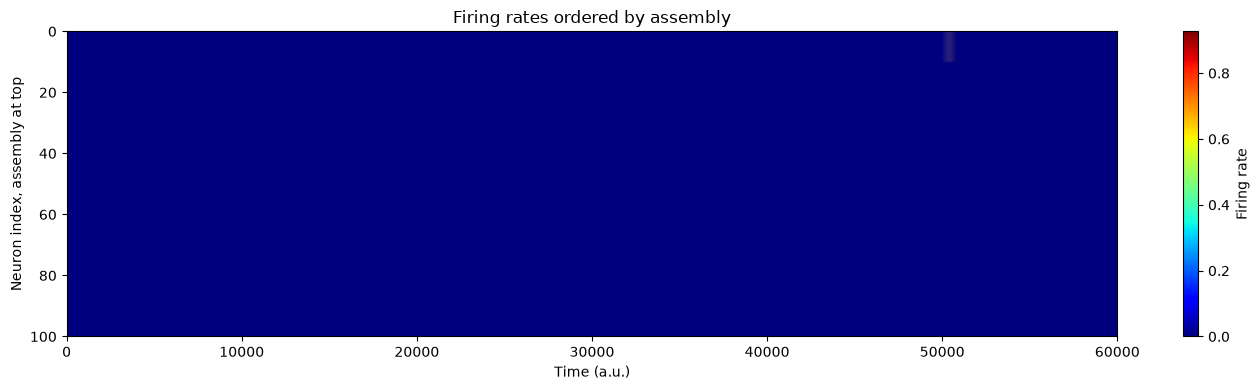

In [47]:
# Plot firing rates heatmap

time_axis = np.arange(n_steps) * dt

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(
    firingRates_ordered,
    aspect='auto',
    cmap='jet',
    origin='upper',
    extent=[time_axis[0], time_axis[-1], firingRates_ordered.shape[0], 0],
)
plt.colorbar(im, ax=ax, label='Firing rate')
ax.set_xlabel('Time (a.u.)')
ax.set_ylabel('Neuron index, assembly at top')
ax.set_title('Firing rates ordered by assembly')
plt.tight_layout()

plt.show()




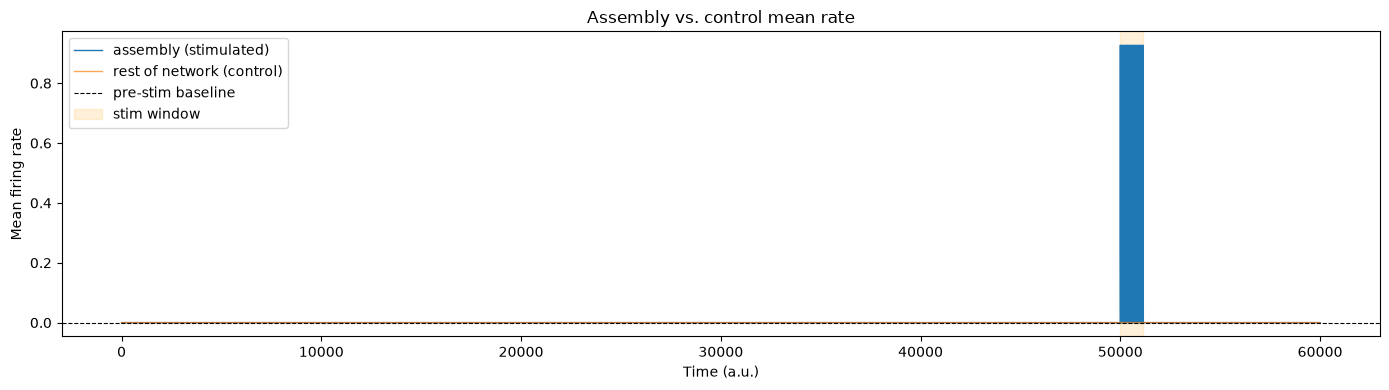

pre-stim  mean assembly rate: 3.059e-07
post-stim mean assembly rate: 3.059e-07
difference: -2.5e-11


In [48]:
# --- Diagnostic: does assembly activity return to baseline after stimulation? ---
# Mean rate is the right summary: a single lingering neuron can keep max() high
# and fake persistence, which is what the heatmap can't rule out.

time_axis = np.arange(n_steps) * dt

mean_assembly = r_ALL[neurons_assembly, :].mean(axis=0)
mean_control  = r_ALL[neurons_NOTassembly, :].mean(axis=0)

pre_mask  = (time_axis > 40000) & (time_axis < tonset_first)   # quiet pre-stim window
post_mask =  time_axis > (toffsets[-1] + 1000)                 # 1000 a.u. after last pulse

baseline_pre  = mean_assembly[pre_mask].mean()
baseline_post = mean_assembly[post_mask].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_axis, mean_assembly, lw=1, label='assembly (stimulated)')
ax.plot(time_axis, mean_control,  lw=1, alpha=0.7, label='rest of network (control)')
ax.axhline(baseline_pre, ls='--', color='k', lw=0.8, label='pre-stim baseline')
ax.axvspan(tonsets[0], toffsets[-1], color='orange', alpha=0.15, label='stim window')
ax.set_xlabel('Time (a.u.)'); ax.set_ylabel('Mean firing rate')
ax.set_title('Assembly vs. control mean rate')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

print(f'pre-stim  mean assembly rate: {baseline_pre:.4g}')
print(f'post-stim mean assembly rate: {baseline_post:.4g}')
print(f'difference: {baseline_post - baseline_pre:+.2g}')

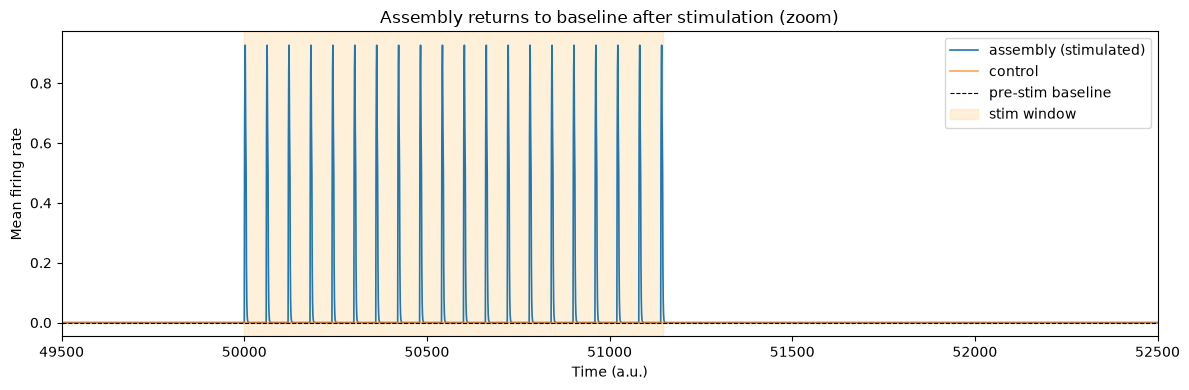

baseline (pre-stim):     3.059e-07
peak during stim:        0.927
returns to within 1%:    3.9 a.u. after stim offset


In [49]:
#Zooming in 

mean_assembly = r_ALL[neurons_assembly, :].mean(axis=0)
mean_control  = r_ALL[neurons_NOTassembly, :].mean(axis=0)

baseline = mean_assembly[(time_axis > 40000) & (time_axis < tonset_first)].mean()
peak     = mean_assembly.max()
last_off = toffsets[-1]

# time to return to within 1% of the (peak - baseline) range after stim ends
post_idx = np.where(time_axis >= last_off)[0]
tol      = baseline + 0.01 * (peak - baseline)
returned = post_idx[mean_assembly[post_idx] <= tol]
t_return = time_axis[returned[0]] - last_off if returned.size else np.nan

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_axis, mean_assembly, lw=1.2, label='assembly (stimulated)')
ax.plot(time_axis, mean_control,  lw=1.2, alpha=0.7, label='control')
ax.axhline(baseline, ls='--', color='k', lw=0.8, label='pre-stim baseline')
ax.axvspan(tonsets[0], toffsets[-1], color='orange', alpha=0.15, label='stim window')
ax.set_xlim(49500, 52500)                       # zoom onto stim + recovery
ax.set_xlabel('Time (a.u.)'); ax.set_ylabel('Mean firing rate')
ax.set_title('Assembly returns to baseline after stimulation (zoom)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

print(f'baseline (pre-stim):     {baseline:.4g}')
print(f'peak during stim:        {peak:.4g}')
print(f'returns to within 1%:    {t_return:.1f} a.u. after stim offset')

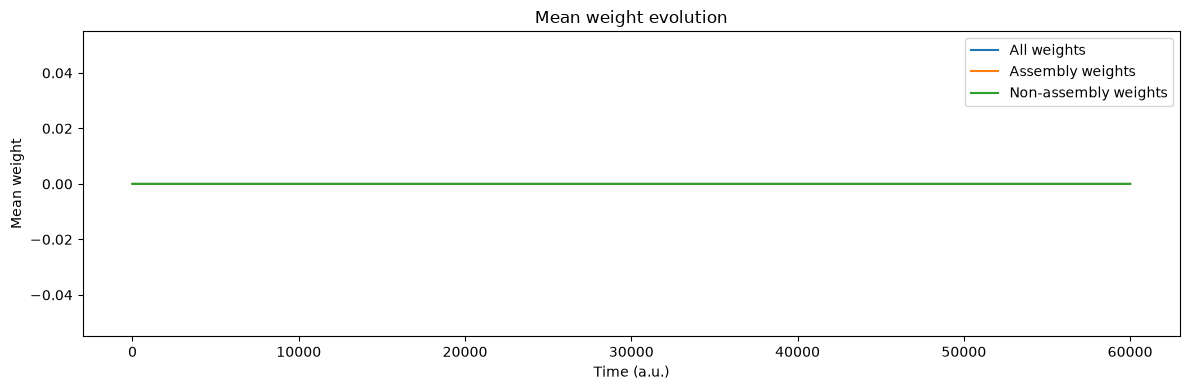

In [50]:
# Plot weight evolution summary

time_axis = np.arange(n_steps) * dt

plt.figure(figsize=(12, 4))
plt.plot(time_axis, mean_weights, label='All weights')
plt.plot(time_axis, mean_weights_assembly, label='Assembly weights')
plt.plot(time_axis, mean_weights_NOTassembly, label='Non-assembly weights')
plt.xlabel('Time (a.u.)')
plt.ylabel('Mean weight')
plt.title('Mean weight evolution')
plt.legend()
plt.tight_layout()


plt.show()




## Week 2 — weight evolution

Tracks the intra-assembly mean weight over the full run and samples it at each stimulation onset,
showing how repeated stimulation drives Hebbian potentiation up toward `Wmax`. *cf. Fig. 4A.*


In [ ]:
# Setup parameters
tmax = 55500          # milestone week 2


LR = 1
beta = 0.0025
tau_w = 50


In [58]:
# Run simulation

print('Starting simulation...')

teta_adapt_before = np.ones(N, dtype=MEMORY_DTYPE) * h0
W_before = np.zeros((N, N), dtype=MEMORY_DTYPE)
r_ALL[:, 0] = r0
teta_adapt_ALL[:, 0] = teta_adapt_before

count_WM = 0
WM_saved = []
count_temp = 2
t_temp = dt
count_temp_first = count_temp
t_temp_first = t_temp
countForSavingWeightMatrix = 0
countMatSaved = 0
D_teta_temp = D_teta

while t_temp < tmax:
    countForSavingWeightMatrix += 1
    ct = count_temp

    in_stim = bool(np.any((tonsets <= t_temp) & (toffsets > t_temp)))

    # Scaling factor
    if ct > 2:
        SF, SF_r, SF_w = compute_SF(r_ALL[:, ct - 2], W_before)
    else:
        SF = SF_r = SF_w = np.ones(N, dtype=MEMORY_DTYPE)

    # Input logic matching the original MATLAB behaviour:
    # outside stim window -> I zeros; in stim window -> I1 assembly input
    #ext_input = I if in_stim else I1 week 1
    ext_input = I1 if in_stim else I

    h = (W_before @ r_ALL[:, ct - 2] + ext_input) * SF

    Input_saved_WithI_WithSc[:, ct - 1] = h
    SF_time[:, ct - 1] = SF
    SF_time_rates[:, ct - 1] = SF_r
    SF_time_weights[:, ct - 1] = SF_w

    noise = C_noise * np.random.randn(N).astype(MEMORY_DTYPE)
    fi = r_max / (1.0 + np.exp(-b * (h - teta_adapt_before)))

    r_ALL[:, ct - 1] = (
        r_ALL[:, ct - 2]
        + (-r_ALL[:, ct - 2] + r0 + fi) * (dt / tau)
        + noise
    )

    teta_adapt = teta_adapt_before + (
        -teta_adapt_before + h0 + D_teta_temp * (r_ALL[:, ct - 2] - r0)
    ) * (dt / tau_teta)
    teta_adapt_ALL[:, ct - 1] = teta_adapt

    # Running mean
    prev_col = ct - 1
    start_col = max(0, prev_col - meanWin + 1)
    meantemp = np.mean(r_ALL[:, start_col:prev_col + 1], axis=1)
    r_i_sub = r_ALL[:, ct - 1] - meantemp

    teta_adapt_before = teta_adapt

    W = (
        W_before
        + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w)
        - beta * W_before * (dt / tau_w)
    )

    if SaturationWeights:
        W = np.clip(W, Wmin, Wmax)
    if NoNegativeWeights:
        W = np.maximum(W, 0.0)
    if not autoconnections:
        np.fill_diagonal(W, 0.0)

    W_before = W.astype(MEMORY_DTYPE, copy=False)

    # Statistics
    mean_weights[ct - 1] = np.mean(W_before)
    std_weights_all[ct - 1] = np.std(W_before)

    Waa = W_before[np.ix_(neurons_assembly, neurons_assembly)]
    mean_weights_assembly[ct - 1] = np.mean(Waa)
    std_weights_assembly[ct - 1] = np.std(Waa)

    Wbb = W_before[np.ix_(neurons_NOTassembly, neurons_NOTassembly)]
    mean_weights_NOTassembly[ct - 1] = np.mean(Wbb)
    std_weights_NOTassembly[ct - 1] = np.std(Wbb)

    mean_weight_outsideTOinside[:, ct - 1] = np.mean(
        W_before[np.ix_(neurons_assembly, neurons_NOTassembly)], axis=0
    )

    # Save weight matrix checkpoints
    flag_stim_onset = bool(np.any((t_temp - tonsets >= 0) & (t_temp - tonsets < dt)))
    flag_after_stim = bool(np.any((t_temp - t_AfterStim > 0) & (t_temp - t_AfterStim < dt)))
    flag_pre_stim = (
        ct > int(45000 / dt)
        and ct < int(tonset_first / dt)
        and countForSavingWeightMatrix >= 2000
    )

    if flag_pre_stim or flag_stim_onset or flag_after_stim:
        countMatSaved += 1
        Ordered = save_weight_matrix(W_before, ct, countMatSaved)
        WM_saved.append(Ordered)
        count_WM += 1
        countForSavingWeightMatrix = 0

    t_temp += dt
    count_temp += 1

    if count_temp % 100000 == 0:
        print(f'  t = {t_temp:.0f} / {tmax}  step = {count_temp:,}')

print('Simulation complete.')
print('Saved weight matrices:', count_WM)


Starting simulation...
  t = 10000 / 55500  step = 100,000
  t = 20000 / 55500  step = 200,000
  t = 30000 / 55500  step = 300,000
  t = 40000 / 55500  step = 400,000
  t = 50000 / 55500  step = 500,000
Simulation complete.
Saved weight matrices: 88


In [59]:
# Save variables

firingRates_ordered = np.vstack([
    r_ALL[neurons_assembly, :],
    r_ALL[neurons_NOTassembly, :]
])

if SAVING_RESULTS:
    split = 2_500_000
    np.save(os.path.join(save_dir, 'AllRates_1.npy'), r_ALL[:, :split])
    np.save(os.path.join(save_dir, 'AllRates_2.npy'), r_ALL[:, split:])
    np.save(os.path.join(save_dir, 'AllTeta_1.npy'), teta_adapt_ALL[:, :split])
    np.save(os.path.join(save_dir, 'AllTeta_2.npy'), teta_adapt_ALL[:, split:])
    np.save(os.path.join(save_dir, 'SF_time_rates_1.npy'), SF_time_rates[:, :split])
    np.save(os.path.join(save_dir, 'SF_time_rates_2.npy'), SF_time_rates[:, split:])
    np.save(os.path.join(save_dir, 'SF_time_weights_1.npy'), SF_time_weights[:, :split])
    np.save(os.path.join(save_dir, 'SF_time_weights_2.npy'), SF_time_weights[:, split:])
    np.save(
        os.path.join(save_dir, 'mean_weight_outsideTOinside_1.npy'),
        mean_weight_outsideTOinside[:, :split]
    )
    np.save(
        os.path.join(save_dir, 'mean_weight_outsideTOinside_2.npy'),
        mean_weight_outsideTOinside[:, split:]
    )
    np.save(
        os.path.join(save_dir, 'Inputparam_WithI_WithSc_1.npy'),
        Input_saved_WithI_WithSc[:, :split]
    )
    np.save(
        os.path.join(save_dir, 'Inputparam_WithI_WithSc_2.npy'),
        Input_saved_WithI_WithSc[:, split:]
    )

    param = dict(
        N=N,
        tmax=tmax,
        beta=beta,
        LR=LR,
        dt=dt,
        tau=tau,
        HMS=HowManyStims,
        toffset_first=toffset_first,
        tonset_first=tonset_first,
        toffsets=toffsets,
        tonsets=tonsets,
        tsep=tsep,
        autoconnections=autoconnections,
        neurons_assembly=neurons_assembly,
        neurons_NOTassembly=neurons_NOTassembly,
        NoiseFactorRATE=Noise_Factor_RATE,
        NoNegativeWeights=NoNegativeWeights,
        SaturationWeights=SaturationWeights,
        Wmax=Wmax,
        Wmin=Wmin,
        r_max=r_max,
        h0=h0,
        b=b,
        count_temp_first=count_temp_first,
        t_temp_first=t_temp_first,
        D=D_teta,
        tau_teta=tau_teta,
        teta_adapt=teta_adapt,
        meanWin=meanWin,
        mean_weights_assembly=mean_weights_assembly,
        std_weights_assembly=std_weights_assembly,
        mean_weights_NOTassembly=mean_weights_NOTassembly,
        std_weights_NOTassembly=std_weights_NOTassembly,
        mean_weights=mean_weights,
        std_weights=std_weights_all,
        Factor_SR=Factor_SR,
        Factor_SW=Factor_SW,
        SR_thr=SR_thr,
        SW_thr=SW_thr,
        HowManyAfterStim=HowManyAfterStim,
        IntervalTest_AfterStim=IntervalTest_AfterStim,
    )

    with open(os.path.join(save_dir, 'param.pkl'), 'wb') as f:
        pickle.dump(param, f)

    print(f'Results saved to: {save_dir}/')


Results saved to: ./attractor_network_results/


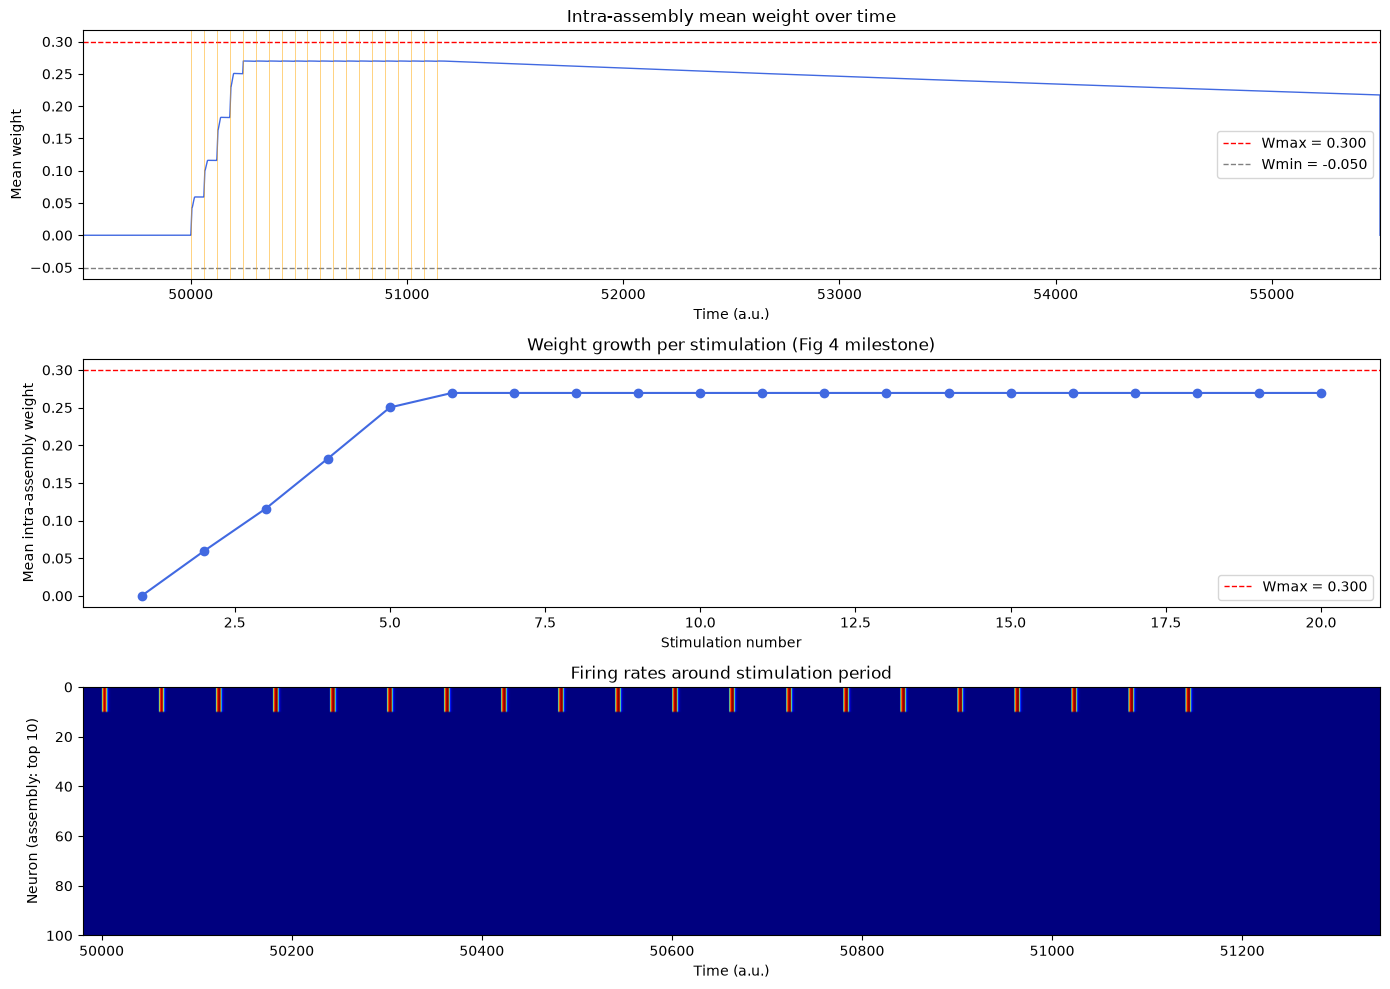

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

time_axis = np.arange(n_steps) * dt

# 1. Intra-assembly mean weight over time
axes[0].plot(time_axis, mean_weights_assembly, color='royalblue', lw=1)
axes[0].axhline(Wmax, color='red', linestyle='--', lw=1, label=f'Wmax = {Wmax:.3f}')
axes[0].axhline(Wmin, color='gray', linestyle='--', lw=1, label=f'Wmin = {Wmin:.3f}')
for ton in tonsets:
    axes[0].axvline(ton, color='orange', alpha=0.5, lw=0.7)
axes[0].set_xlim([tonset_first - 500, tmax])
axes[0].set_xlabel('Time (a.u.)')
axes[0].set_ylabel('Mean weight')
axes[0].set_title('Intra-assembly mean weight over time')
axes[0].legend()

# 2. Mean weight sampled at each stim onset (the Fig 4A equivalent)
weights_per_stim = []
for ton in tonsets:
    idx = int(ton / dt)
    weights_per_stim.append(mean_weights_assembly[idx])

axes[1].plot(range(1, HowManyStims + 1), weights_per_stim, 'o-', color='royalblue')
axes[1].axhline(Wmax, color='red', linestyle='--', lw=1, label=f'Wmax = {Wmax:.3f}')
axes[1].set_xlabel('Stimulation number')
axes[1].set_ylabel('Mean intra-assembly weight')
axes[1].set_title('Weight growth per stimulation (Fig 4 milestone)')
axes[1].legend()

# 3. Firing rates heatmap zoomed around stim period
zoom_start = int((tonset_first - 20) / dt)
zoom_end   = int((toffsets[-1] + 200) / dt)
axes[2].imshow(
    firingRates_ordered[:, zoom_start:zoom_end],
    aspect='auto', cmap='jet', origin='upper',
    extent=[time_axis[zoom_start], time_axis[zoom_end],
            firingRates_ordered.shape[0], 0]
)
axes[2].set_xlabel('Time (a.u.)')
axes[2].set_ylabel('Neuron (assembly: top 10)')
axes[2].set_title('Firing rates around stimulation period')

plt.tight_layout()

plt.show()

## Week 3 — stability check

Verifies the network stays well-behaved over the whole simulation, including the long
post-stimulation window: weights and firing rates stay bounded, and the forgetting term (`beta`)
pulls unused weights back toward zero. Ends with an automated pass/fail summary. *cf. Fig. 2B.*


In [66]:
# Setup parameters
tmax = 100000  # milestone week 3

# Recalculate n_steps and reallocate arrays for the new tmax
n_steps = int(tmax / dt) + 1

mean_weight_outsideTOinside = np.zeros((len(neurons_NOTassembly), n_steps), dtype=MEMORY_DTYPE)
mean_weights_assembly       = np.zeros(n_steps, dtype=MEMORY_DTYPE)
mean_weights_NOTassembly    = np.zeros(n_steps, dtype=MEMORY_DTYPE)
std_weights_assembly        = np.zeros(n_steps, dtype=MEMORY_DTYPE)
std_weights_NOTassembly     = np.zeros(n_steps, dtype=MEMORY_DTYPE)
r_ALL                       = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
Input_saved_WithI_WithSc    = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
SF_time                     = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
SF_time_weights             = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
SF_time_rates               = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
teta_adapt_ALL              = np.zeros((N, n_steps), dtype=MEMORY_DTYPE)
mean_weights                = np.zeros(n_steps, dtype=MEMORY_DTYPE)
std_weights_all             = np.zeros(n_steps, dtype=MEMORY_DTYPE)

print(f'n_steps = {n_steps:,}  →  arrays reallocated')

n_steps = 1,000,001  →  arrays reallocated


In [67]:
# Run simulation

print('Starting simulation...')

teta_adapt_before = np.ones(N, dtype=MEMORY_DTYPE) * h0
W_before = np.zeros((N, N), dtype=MEMORY_DTYPE)
r_ALL[:, 0] = r0
teta_adapt_ALL[:, 0] = teta_adapt_before

count_WM = 0
WM_saved = []
count_temp = 2
t_temp = dt
count_temp_first = count_temp
t_temp_first = t_temp
countForSavingWeightMatrix = 0
countMatSaved = 0
D_teta_temp = D_teta

while t_temp < tmax - dt * 0.5:
    countForSavingWeightMatrix += 1
    ct = count_temp

    in_stim = bool(np.any((tonsets <= t_temp) & (toffsets > t_temp)))

    # Scaling factor
    if ct > 2:
        SF, SF_r, SF_w = compute_SF(r_ALL[:, ct - 2], W_before)
    else:
        SF = SF_r = SF_w = np.ones(N, dtype=MEMORY_DTYPE)

    # Input logic matching the original MATLAB behaviour:
    # outside stim window -> I zeros; in stim window -> I1 assembly input
    #ext_input = I if in_stim else I1 week 1
    ext_input = I1 if in_stim else I

    h = (W_before @ r_ALL[:, ct - 2] + ext_input) * SF

    Input_saved_WithI_WithSc[:, ct - 1] = h
    SF_time[:, ct - 1] = SF
    SF_time_rates[:, ct - 1] = SF_r
    SF_time_weights[:, ct - 1] = SF_w

    noise = C_noise * np.random.randn(N).astype(MEMORY_DTYPE)
    fi = r_max / (1.0 + np.exp(-b * (h - teta_adapt_before)))

    r_ALL[:, ct - 1] = (
        r_ALL[:, ct - 2]
        + (-r_ALL[:, ct - 2] + r0 + fi) * (dt / tau)
        + noise
    )

    teta_adapt = teta_adapt_before + (
        -teta_adapt_before + h0 + D_teta_temp * (r_ALL[:, ct - 2] - r0)
    ) * (dt / tau_teta)
    teta_adapt_ALL[:, ct - 1] = teta_adapt

    # Running mean
    prev_col = ct - 1
    start_col = max(0, prev_col - meanWin + 1)
    meantemp = np.mean(r_ALL[:, start_col:prev_col + 1], axis=1)
    r_i_sub = r_ALL[:, ct - 1] - meantemp

    teta_adapt_before = teta_adapt

    W = (
        W_before
        + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w)
        - beta * W_before * (dt / tau_w)
    )

    if SaturationWeights:
        W = np.clip(W, Wmin, Wmax)
    if NoNegativeWeights:
        W = np.maximum(W, 0.0)
    if not autoconnections:
        np.fill_diagonal(W, 0.0)

    W_before = W.astype(MEMORY_DTYPE, copy=False)

    # Statistics
    mean_weights[ct - 1] = np.mean(W_before)
    std_weights_all[ct - 1] = np.std(W_before)

    Waa = W_before[np.ix_(neurons_assembly, neurons_assembly)]
    mean_weights_assembly[ct - 1] = np.mean(Waa)
    std_weights_assembly[ct - 1] = np.std(Waa)

    Wbb = W_before[np.ix_(neurons_NOTassembly, neurons_NOTassembly)]
    mean_weights_NOTassembly[ct - 1] = np.mean(Wbb)
    std_weights_NOTassembly[ct - 1] = np.std(Wbb)

    mean_weight_outsideTOinside[:, ct - 1] = np.mean(
        W_before[np.ix_(neurons_assembly, neurons_NOTassembly)], axis=0
    )

    # Save weight matrix checkpoints
    flag_stim_onset = bool(np.any((t_temp - tonsets >= 0) & (t_temp - tonsets < dt)))
    flag_after_stim = bool(np.any((t_temp - t_AfterStim > 0) & (t_temp - t_AfterStim < dt)))
    flag_pre_stim = (
        ct > int(45000 / dt)
        and ct < int(tonset_first / dt)
        and countForSavingWeightMatrix >= 2000
    )

    if flag_pre_stim or flag_stim_onset or flag_after_stim:
        countMatSaved += 1
        Ordered = save_weight_matrix(W_before, ct, countMatSaved)
        WM_saved.append(Ordered)
        count_WM += 1
        countForSavingWeightMatrix = 0

    t_temp += dt
    count_temp += 1

    if count_temp % 100000 == 0:
        print(f'  t = {t_temp:.0f} / {tmax}  step = {count_temp:,}')

print('Simulation complete.')
print('Saved weight matrices:', count_WM)


Starting simulation...
  t = 10000 / 100000  step = 100,000
  t = 20000 / 100000  step = 200,000
  t = 30000 / 100000  step = 300,000
  t = 40000 / 100000  step = 400,000
  t = 50000 / 100000  step = 500,000
  t = 60000 / 100000  step = 600,000
  t = 70000 / 100000  step = 700,000
  t = 80000 / 100000  step = 800,000
  t = 90000 / 100000  step = 900,000
  t = 100000 / 100000  step = 1,000,000
Simulation complete.
Saved weight matrices: 145


In [68]:
# Save variables

firingRates_ordered = np.vstack([
    r_ALL[neurons_assembly, :],
    r_ALL[neurons_NOTassembly, :]
])

if SAVING_RESULTS:
    split = 2_500_000
    np.save(os.path.join(save_dir, 'AllRates_1.npy'), r_ALL[:, :split])
    np.save(os.path.join(save_dir, 'AllRates_2.npy'), r_ALL[:, split:])
    np.save(os.path.join(save_dir, 'AllTeta_1.npy'), teta_adapt_ALL[:, :split])
    np.save(os.path.join(save_dir, 'AllTeta_2.npy'), teta_adapt_ALL[:, split:])
    np.save(os.path.join(save_dir, 'SF_time_rates_1.npy'), SF_time_rates[:, :split])
    np.save(os.path.join(save_dir, 'SF_time_rates_2.npy'), SF_time_rates[:, split:])
    np.save(os.path.join(save_dir, 'SF_time_weights_1.npy'), SF_time_weights[:, :split])
    np.save(os.path.join(save_dir, 'SF_time_weights_2.npy'), SF_time_weights[:, split:])
    np.save(
        os.path.join(save_dir, 'mean_weight_outsideTOinside_1.npy'),
        mean_weight_outsideTOinside[:, :split]
    )
    np.save(
        os.path.join(save_dir, 'mean_weight_outsideTOinside_2.npy'),
        mean_weight_outsideTOinside[:, split:]
    )
    np.save(
        os.path.join(save_dir, 'Inputparam_WithI_WithSc_1.npy'),
        Input_saved_WithI_WithSc[:, :split]
    )
    np.save(
        os.path.join(save_dir, 'Inputparam_WithI_WithSc_2.npy'),
        Input_saved_WithI_WithSc[:, split:]
    )

    param = dict(
        N=N,
        tmax=tmax,
        beta=beta,
        LR=LR,
        dt=dt,
        tau=tau,
        HMS=HowManyStims,
        toffset_first=toffset_first,
        tonset_first=tonset_first,
        toffsets=toffsets,
        tonsets=tonsets,
        tsep=tsep,
        autoconnections=autoconnections,
        neurons_assembly=neurons_assembly,
        neurons_NOTassembly=neurons_NOTassembly,
        NoiseFactorRATE=Noise_Factor_RATE,
        NoNegativeWeights=NoNegativeWeights,
        SaturationWeights=SaturationWeights,
        Wmax=Wmax,
        Wmin=Wmin,
        r_max=r_max,
        h0=h0,
        b=b,
        count_temp_first=count_temp_first,
        t_temp_first=t_temp_first,
        D=D_teta,
        tau_teta=tau_teta,
        teta_adapt=teta_adapt,
        meanWin=meanWin,
        mean_weights_assembly=mean_weights_assembly,
        std_weights_assembly=std_weights_assembly,
        mean_weights_NOTassembly=mean_weights_NOTassembly,
        std_weights_NOTassembly=std_weights_NOTassembly,
        mean_weights=mean_weights,
        std_weights=std_weights_all,
        Factor_SR=Factor_SR,
        Factor_SW=Factor_SW,
        SR_thr=SR_thr,
        SW_thr=SW_thr,
        HowManyAfterStim=HowManyAfterStim,
        IntervalTest_AfterStim=IntervalTest_AfterStim,
    )

    with open(os.path.join(save_dir, 'param.pkl'), 'wb') as f:
        pickle.dump(param, f)

    print(f'Results saved to: {save_dir}/')


Results saved to: ./attractor_network_results/


In [70]:
time_axis = np.arange(n_steps) * dt

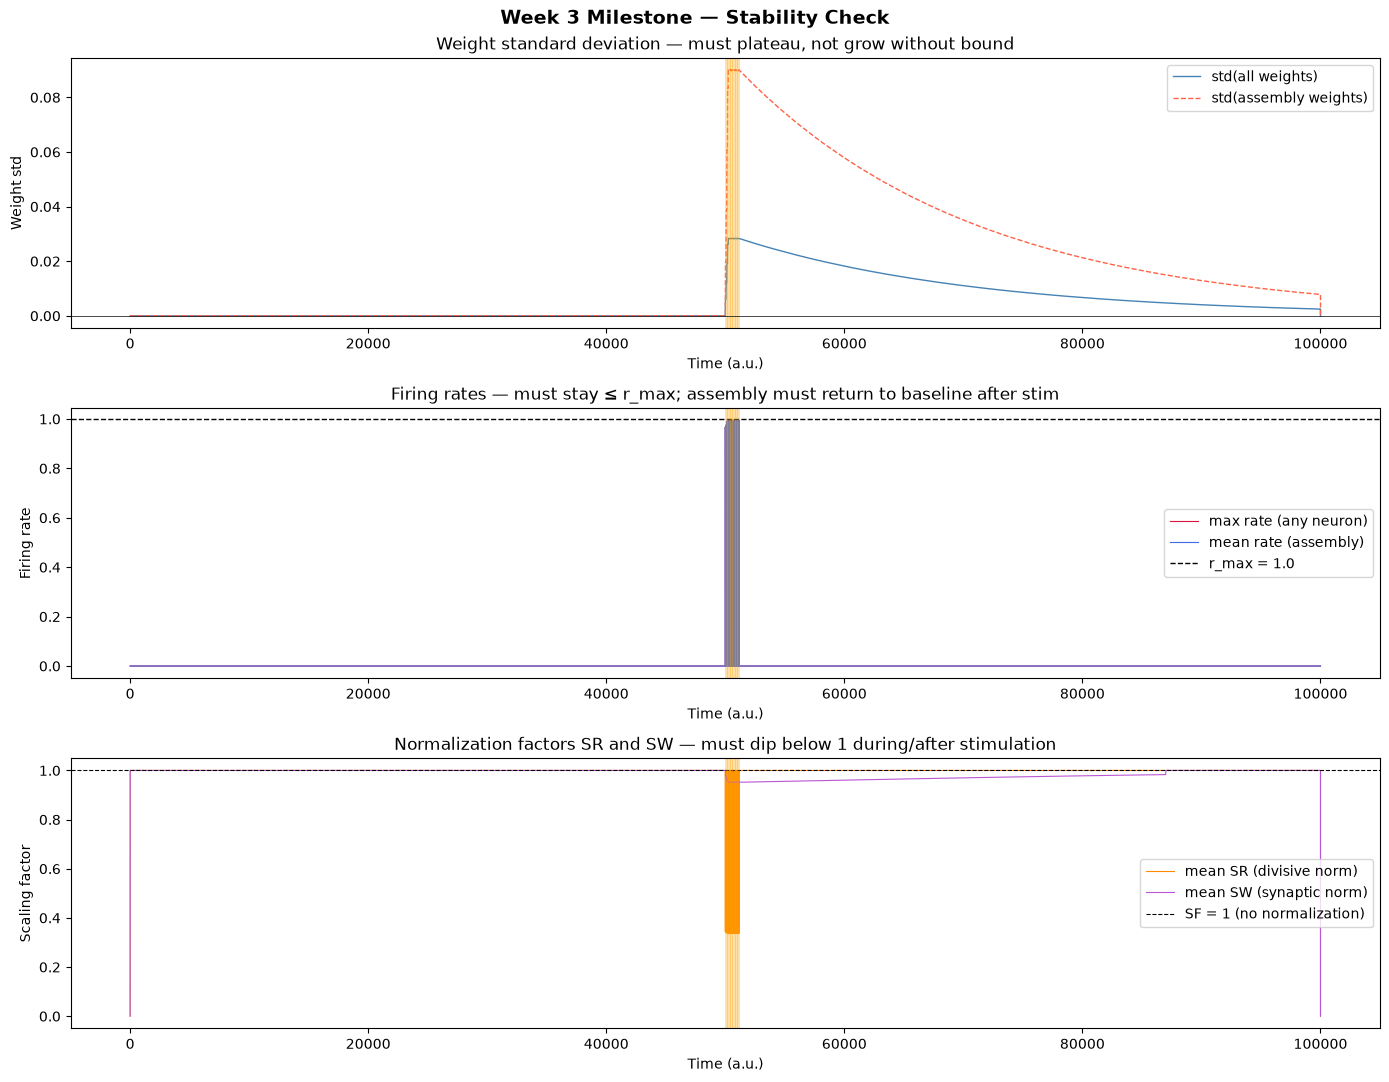

In [ ]:
# Stability check: weights and firing rates must stay bounded over the full
# simulation, including the long post-stimulation window.
#
# Pass criteria:
#   ✅ std(all weights) stays roughly flat after stimulation ends
#   ✅ max firing rate stays ≤ r_max (= 1.0) at all times
#   ✅ mean weight returns toward 0 after stimulation (forgetting)

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('Week 3 Milestone — Stability Check', fontsize=14, fontweight='bold')

# ── Panel 1: Weight std over the FULL simulation ───────────────────────────
# This directly mirrors Fig 2B (right panel) of the paper.
# Without β the std would drift upward without bound; with β it plateaus.
axes[0].plot(time_axis, std_weights_all, color='steelblue', lw=1, label='std(all weights)')
axes[0].plot(time_axis, std_weights_assembly, color='tomato', lw=1,
             linestyle='--', label='std(assembly weights)')
for ton in tonsets:
    axes[0].axvline(ton, color='orange', alpha=0.4, lw=0.6)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('Time (a.u.)'); axes[0].set_ylabel('Weight std')
axes[0].set_title('Weight standard deviation — must plateau, not grow without bound')
axes[0].legend()

# ── Panel 2: Max firing rate over time ─────────────────────────────────────
# If SR (divisive normalization) and SW (synaptic normalization) are
# working, the network should never sustain runaway firing (all rates ≤ r_max).
max_rate = np.max(r_ALL, axis=0)
mean_rate_assembly = np.mean(r_ALL[neurons_assembly, :], axis=0)

axes[1].plot(time_axis, max_rate,           color='crimson', lw=0.8, label='max rate (any neuron)')
axes[1].plot(time_axis, mean_rate_assembly, color='royalblue', lw=0.8, label='mean rate (assembly)')
axes[1].axhline(r_max, color='k', linestyle='--', lw=1, label=f'r_max = {r_max}')
for ton in tonsets:
    axes[1].axvline(ton, color='orange', alpha=0.4, lw=0.6)
axes[1].set_xlabel('Time (a.u.)'); axes[1].set_ylabel('Firing rate')
axes[1].set_title('Firing rates — must stay ≤ r_max; assembly must return to baseline after stim')
axes[1].legend()

# ── Panel 3: Scaling factors over time (SR and SW mean across neurons) ─────
# Shows that the normalization mechanisms are actually active (values < 1).
mean_SF_r = np.mean(SF_time_rates,   axis=0)
mean_SF_w = np.mean(SF_time_weights, axis=0)

axes[2].plot(time_axis, mean_SF_r, color='darkorange',  lw=0.8, label='mean SR (divisive norm)')
axes[2].plot(time_axis, mean_SF_w, color='mediumorchid', lw=0.8, label='mean SW (synaptic norm)')
axes[2].axhline(1.0, color='k', linestyle='--', lw=0.8, label='SF = 1 (no normalization)')
for ton in tonsets:
    axes[2].axvline(ton, color='orange', alpha=0.4, lw=0.6)
axes[2].set_xlabel('Time (a.u.)'); axes[2].set_ylabel('Scaling factor')
axes[2].set_title('Normalization factors SR and SW — must dip below 1 during/after stimulation')
axes[2].legend()

plt.tight_layout()

plt.show()


In [72]:
# ── Quick pass/fail summary ────────────────────────────────────────────────
# ── CELL 10 (corrected summary only) ─────────────────────────────────────
# Replace just the pass/fail block at the bottom of the week3 milestone cell.
# The three plots are unchanged.

post_stim_start = int(toffsets[-1] / dt) + 1
std_post        = std_weights_all[post_stim_start:]
max_rate_global = np.max(r_ALL)

# ── CHECK 1: firing rate ───────────────────────────────────────────────────
# r_max is the sigmoid asymptote, not a hard clip. Noise can push individual
# steps slightly above it during the stimulus. What matters is that firing
# rates don't stay elevated *after* stimulation ends.
mean_rate_post_stim = np.mean(r_ALL[:, post_stim_start:])
max_rate_post_stim  = np.max( r_ALL[:, post_stim_start:])
rate_ok = mean_rate_post_stim < 0.05   # baseline + noise should be well below 0.5

# ── CHECK 2: weight std plateau ────────────────────────────────────────────
# Std should not keep growing. Compare the first quarter vs last quarter
# of the post-stim window.
q = len(std_post) // 4
std_early = np.mean(std_post[:q])
std_late  = np.mean(std_post[3*q:])
std_ok = std_late <= std_early * 1.1   # allow 10 % growth, flag runaway

# ── CHECK 3: normalization active ─────────────────────────────────────────
mean_SF_r   = np.mean(SF_time_rates,   axis=0)
stim_slice  = slice(int(tonset_first / dt), int(toffsets[-1] / dt) + 1)
sf_min_stim = np.min(mean_SF_r[stim_slice])
sf_ok = sf_min_stim < 0.99

print('\n── WEEK 3 STABILITY SUMMARY ──────────────────────────────')
print(f'  Max firing rate (during stim):     {max_rate_global:.4f}  '
      f'[sigmoid asymptote, noise can exceed r_max briefly — expected]')
print(f'  Max firing rate (POST stim only):  {max_rate_post_stim:.4f}  (should be < 0.5)')
print(f'  Mean firing rate (post stim):      {mean_rate_post_stim:.4f}')
print(f'  Weight std — early post-stim:      {std_early:.6f}')
print(f'  Weight std — late post-stim:       {std_late:.6f}  '
      f'(should be ≤ early × 1.1 = {std_early*1.1:.6f})')
print(f'  Min SR during stim window:         {sf_min_stim:.4f}  (should be < 1.0)')

print()
if rate_ok:
    print('  ✅ Firing rates return to baseline after stim — no runaway activation.')
else:
    print('  ❌ Firing rates sustained post-stim — check SR / SW strengths.')

if std_ok:
    print('  ✅ Weight std stable (forgetting term working).')
else:
    print('  ❌ Weight std still growing post-stim — check β value.')

if sf_ok:
    print('  ✅ Normalization factors active during stimulation.')
else:
    print('  ⚠️  SR barely below 1 — check Factor_SR and network activity.')

if rate_ok and std_ok and sf_ok:
    print()
    print('  🎉 WEEK 3 MILESTONE PASSED — network is stable.')
print('──────────────────────────────────────────────────────────')


── WEEK 3 STABILITY SUMMARY ──────────────────────────────
  Max firing rate (during stim):     0.9948  [sigmoid asymptote, noise can exceed r_max briefly — expected]
  Max firing rate (POST stim only):  0.8954  (should be < 0.5)
  Mean firing rate (post stim):      0.0000
  Weight std — early post-stim:      0.021221
  Weight std — late post-stim:       0.003397  (should be ≤ early × 1.1 = 0.023343)
  Min SR during stim window:         0.3369  (should be < 1.0)

  ✅ Firing rates return to baseline after stim — no runaway activation.
  ✅ Weight std stable (forgetting term working).
  ✅ Normalization factors active during stimulation.

  🎉 WEEK 3 MILESTONE PASSED — network is stable.
──────────────────────────────────────────────────────────


## Week 4 — Frequency-dependent assembly growth

How does the **rate of stimulation** shape a memory? We stimulate a single assembly at several
onset frequencies and measure how large and how strong it becomes. Faster co-presentation → more
Hebbian potentiation before forgetting can act. *cf. Fig. 4.*


In [5]:
import time

In [6]:
def sigmoid(x):
    """Sigmoidal transfer function (Eq 3)"""
    return 1.0 / (1.0 + np.exp(-b * x))


def compute_scaling(r_prev, W_prev): #same as def compute_SF
    """Compute normalization scaling factors (Eq 9 & 10)"""
    #Divisive normalization (scales based on network activity)
    r_hside = r_prev * _heaviside(r_prev - SR_thr)
    r_without = np.sum(r_hside) - r_hside
    SR_den = 1.0 + (r_without / HowManyStimNeurons) * Factor_SR
    SF_r = 1.0 / SR_den

    #Synaptic normalization (scales based on incoming weights)
    W_hside = W_prev * _heaviside(W_prev - SW_thr)
    sum_IncomingW = np.sum(W_hside, axis=1)
    SW_den = 1.0 + sum_IncomingW * Factor_SW
    SF_w = 1.0 / np.sqrt(SW_den)
    
    return SF_w * SF_r, SF_r, SF_w

def get_assembly_size(W, assembly_neurons, threshold=0.1):
    """Count neurons in the assembly"""
    incoming = np.mean(W[:, assembly_neurons], axis=1)
    return np.sum(incoming > threshold)

def run_frequency(freq, total_time=480000):
    """
    Run simulation for a single frequency.
    """
    tsep = int(1/freq)
    n_stims = int((total_time - 5000) / tsep)
    
    print(f"\n  Frequency: {freq:.4f} (tsep={tsep}, n_stims={n_stims})")
    
    # --- Setup ---
    np.random.seed(int(freq * 10000))
    
    # Choose assembly neurons
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    assembly_neurons = all_neurons[:HowManyStimNeurons]
    
    # Stimulation schedule
    tonsets = np.array([50000 + i * tsep for i in range(n_stims)])
    toffsets = np.array([50005 + i * tsep for i in range(n_stims)])
    
    # Inputs
    I = np.zeros(N)
    I1 = I.copy()
    I1[assembly_neurons] = 1.0
    
    # --- State ---
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    # --- Storage ---
    times = []
    assembly_sizes = []
    mean_weights = []
    
    # --- Helper ---
    def is_stimulating(t):
        return np.any((tonsets <= t) & (toffsets > t))
    
    # --- Simulation Loop ---
    t = 0
    step = 0
    record_every = 1000  # Record every 1000 steps
    
    while t < total_time:
        in_stim = is_stimulating(t)
        ext_input = I1 if in_stim else I
        
        # Compute input with normalization
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)
        
        h = (W @ r + ext_input) * SF
        
        # Update rates
        noise = C_noise * np.random.randn(N)
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        
        # Update threshold
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        # Learning
        if step > 10:
            # Running mean
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            # Hebbian learning
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            # Clip weights
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
        
        # Record
        if step % record_every == 0 and step > 10:
            size = get_assembly_size(W, assembly_neurons)
            mean_w = np.mean(W[np.ix_(assembly_neurons, assembly_neurons)])
            times.append(t)
            assembly_sizes.append(size)
            mean_weights.append(mean_w)
        
        # Update
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
    
    # --- Results ---
    print(f"    Final assembly size: {assembly_sizes[-1] if assembly_sizes else HowManyStimNeurons}")
    
    results = {
        'freq': freq,
        'tsep': tsep,
        'n_stims': n_stims,
        'times': np.array(times),
        'assembly_sizes': np.array(assembly_sizes),
        'mean_weights': np.array(mean_weights),
        'final_W': W,
        'assembly_neurons': assembly_neurons,
        'final_size': assembly_sizes[-1] if assembly_sizes else HowManyStimNeurons,
    }
    
    return results


#### Run experiment

In [ ]:
def run_experiment(frequencies=[1/30, 1/40, 1/60, 1/120], 
                   total_time=480000):
    """
    Run the full frequency experiment (no saving).
    """
    print("="*70)
    print("WEEK 4: FREQUENCY-DEPENDENT GROWTH EXPERIMENT")
    print("="*70)
    print(f"Frequencies: {frequencies}")
    print(f"Total time: {total_time} a.u.")
    print("="*70)
    
    results = {}
    
    for freq in frequencies:
        result = run_frequency(freq, total_time)
        results[freq] = result
    
    return results

In [ ]:
# Quick smoke test on a single frequency to confirm the pipeline runs end-to-end
test_results = run_experiment(frequencies=[1/30], total_time=60000)

#### Plot results

In [ ]:
def plot_results(results, save_path=None):
    """
    Plot Figure 6 from results.
    """
    freqs = sorted(results.keys())
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(freqs)))
    
    # Plot 1: Assembly size over time
    ax1 = axes[0, 0]
    for i, freq in enumerate(freqs):
        r = results[freq]
        ax1.plot(r['times'], r['assembly_sizes'], 
                label=f'f={freq:.4f} (1/{int(1/freq)})',
                color=colors[i], linewidth=2)
    ax1.set_xlabel('Time (a.u.)')
    ax1.set_ylabel('Assembly Size')
    ax1.set_title('Assembly Growth Over Time')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Figure 6 - Final size vs frequency
    ax2 = axes[0, 1]
    final_sizes = [results[freq]['final_size'] for freq in freqs]
    ax2.plot(freqs, final_sizes, 'o-', color='darkblue', linewidth=2, markersize=10)
    for freq, size in zip(freqs, final_sizes):
        ax2.annotate(f'1/{int(1/freq)}', (freq, size), xytext=(5, 5), 
                    textcoords='offset points')
    ax2.set_xlabel('Stimulation Frequency (1/a.u.)')
    ax2.set_ylabel('Final Assembly Size')
    ax2.set_title('Figure 6: Frequency-Dependent Assembly Growth')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=10, color='gray', linestyle='--', alpha=0.5, label='Initial size')
    ax2.legend()
    
    # Plot 3: Mean weight over time
    ax3 = axes[1, 0]
    for i, freq in enumerate(freqs):
        r = results[freq]
        ax3.plot(r['times'], r['mean_weights'], 
                label=f'f={freq:.4f}', color=colors[i], linewidth=2)
    ax3.set_xlabel('Time (a.u.)')
    ax3.set_ylabel('Mean Assembly Weight')
    ax3.set_title('Synaptic Strength Growth')
    ax3.legend(loc='best')
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([-0.01, 0.32])
    
    # Plot 4: Weight matrix (highest frequency)
    ax4 = axes[1, 1]
    highest_freq = max(freqs)
    r = results[highest_freq]
    W = r['final_W']
    assembly = r['assembly_neurons']
    
    # Reorder matrix: assembly neurons first
    all_idx = np.arange(W.shape[0])
    bg_idx = [i for i in all_idx if i not in assembly]
    order = list(assembly) + bg_idx
    W_ordered = W[np.ix_(order, order)]
    
    im = ax4.imshow(W_ordered, cmap='RdBu_r', aspect='auto', vmin=-0.05, vmax=0.3)
    ax4.set_title(f'Weight Matrix (Highest Frequency: 1/{int(1/highest_freq)})')
    ax4.set_xlabel('Neuron Index')
    ax4.set_ylabel('Neuron Index')
    ax4.axhline(y=len(assembly)-0.5, color='white', linestyle='--', alpha=0.5)
    ax4.axvline(x=len(assembly)-0.5, color='white', linestyle='--', alpha=0.5)
    plt.colorbar(im, ax=ax4, label='Synaptic Weight')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    return fig


#### Summary table

In [ ]:
def print_summary(results):
    """Print summary table of results."""
    print("\n" + "="*70)
    print("SUMMARY TABLE")
    print("="*70)
    print(f"{'Frequency':>12} {'tsep':>8} {'Stims':>10} {'Final Size':>12} {'Growth':>10}")
    print("-"*70)
    
    for freq in sorted(results.keys()):
        r = results[freq]
        growth = r['final_size'] - HowManyStimNeurons
        print(f"{freq:>12.4f} {r['tsep']:>8} {r['n_stims']:>10} {r['final_size']:>12} {growth:>10}")
    print("="*70)

#### Run

In [ ]:
# Full Week 4 run (heavy: total_time = 480000). Lower total_time for a quick preview.
if __name__ == "__main__":
    
    total_time = 480000  # Full run
    frequencies = [1/30, 1/40, 1/60, 1/120]
    
    print("\n" + "="*70)
    print("RUNNING WEEK 4 EXPERIMENT")
    print("="*70)
    print(f"Total time: {total_time} a.u.")
    print(f"Frequencies: {frequencies}")
    print("="*70)
    
    start_time = time.time()
    
    # Run experiment
    results = run_experiment(frequencies, total_time)
    
    # Print summary
    print_summary(results)
    
    # Plot results
    plot_results(results)
    
    elapsed = time.time() - start_time
    print(f"\n✅ Week 4 Complete! (Time: {elapsed:.1f} seconds)")

## Week 5 — Memory competition: reinforcement & forgetting

Several assemblies now coexist and compete. Reinforced (re-stimulated) memories grow and hold their
territory; neglected ones shrink as forgetting erodes their weights. *cf. Fig. 6.*


In [ ]:
def run_competition(total_time=480000):
# our longest stimulation time
# reason: decay is much slower than growth (cut A3 off at t=150000, had to give time afterwards to gradually wear down)

    """
    Week 5: Memory competition and forgetting.
    Runs 3 orthogonal assemblies with different stimulation schedules.
    """
    print("="*70)
    print("WEEK 5: MEMORY COMPETITION AND FORGETTING")
    print("="*70)
    
    # --- Setup Frequencies ---
    tsep1 = 30   # Assembly 1: Frequent
    tsep2 = 120  # Assembly 2: Infrequent
    tsep3 = 30   # Assembly 3: Frequent initially (same as A1), then stopped
    
    stop_time_3 = 150000 # Time when Assembly 3 stops receiving inputs
    

    # Calculate the exact number of stimulations to fit within the time limits.
    # We subtract 50000 because the first stimulation starts at t=50000.
    n_stims1 = int((total_time - 50000) / tsep1)
    n_stims2 = int((total_time - 50000) / tsep2)
    n_stims3 = int((stop_time_3 - 50000) / tsep3)
    
    print(f"Assembly 1 (High freq): tsep={tsep1}, n_stims={n_stims1}")
    print(f"Assembly 2 (Low freq): tsep={tsep2}, n_stims={n_stims2}")
    print(f"Assembly 3 (Stopped): tsep={tsep3}, n_stims={n_stims3} (stops at t={stop_time_3})")
    
    np.random.seed(42) # Fixed seed for reproducible competition
    
    # --- 1. Initialize 3 Orthogonal Assemblies ---
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    # Slice the shuffled list to ensure the assemblies share zero neurons
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[10:20]
    assm3 = all_neurons[20:30]
    
# --- 2. Independent Stimulation Schedules (but phase-shfited) ---
# We add a 10 a.u. delay between each assembly's start time to prevent 
# them from firing at the exact same millisecond and fusing together.

    # A1 starts at 50.000
    tonsets1 = np.array([50000 + i * tsep1 for i in range(n_stims1)])
    toffsets1 = tonsets1 + 5
    
    # A2 starts at 50.010
    tonsets2 = np.array([50010 + i * tsep2 for i in range(n_stims2)])
    toffsets2 = tonsets2 + 5
    
    # A3 starts at 50.020
    tonsets3 = np.array([50020 + i * tsep3 for i in range(n_stims3)])
    toffsets3 = tonsets3 + 5
    
    # --- State Variables ---
    W = np.zeros((N, N))   # Weight matrix
    r = np.zeros(N)        # Firing rates
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N) # Running mean firing rate
    mean_rate_initialized = False
    
    # --- Storage Arrays ---
    times = []
    sizes = {'A1': [], 'A2': [], 'A3': []}
    weights = {'A1': [], 'A2': [], 'A3': []}
    
    # --- Simulation Loop ---
    t = 0
    step = 0
    record_every = 1000 # Save data every 1000 steps to save memory

    
    while t < total_time:
        # Reset external input to zero for this timestep
        ext_input = np.zeros(N)
        
        # Check if current time 't' falls within any stimulation window.
        # If yes, apply current (1.0) to those specific neurons.
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
        if np.any((tonsets3 <= t) & (toffsets3 > t)):
            ext_input[assm3] = 1.0
            
        # Compute input with normalization scaling factors
        # to keep network stable
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)

        # Compute total input (weights * rates + external input) * scaling factor    
        h = (W @ r + ext_input) * SF
        
        # Update firing rates using sigmoid transfer function
        noise = C_noise * np.random.randn(N) # Add background noise for accidental recruitment
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        
        # Update threshold
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        # ------- Learning phase -------
        if step > 10:  # Wait a few steps for the network to stabilize
            # calculate the running mean of firing rates
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            

            # Apply Hebbian Learning: Learning Rate (LR) minus Forgetting Factor (beta)
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            # Keep weights within physical boundaries [Wmin, Wmax]
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            # Remove self-connections (neurons cannot connect to themselves)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        # ---------- Record Data -----------
        if step % record_every == 0 and step > 10:
            times.append(t)
            
            # Calculate and save the current size of each assembly            sizes['A1'].append(get_assembly_size(W, assm1))
            sizes['A2'].append(get_assembly_size(W, assm2))
            sizes['A3'].append(get_assembly_size(W, assm3))
            
            # Record mean weights
            weights['A1'].append(np.mean(W[np.ix_(assm1, assm1)]))
            weights['A2'].append(np.mean(W[np.ix_(assm2, assm2)]))
            weights['A3'].append(np.mean(W[np.ix_(assm3, assm3)]))

        # Move variables to the next timestep    
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    # --- Results Dictionary ---
    results = {
        'times': np.array(times),
        'sizes': sizes,
        'weights': weights,
        'final_W': W,
        'assemblies': {'A1': assm1, 'A2': assm2, 'A3': assm3}
    }
    
    return results

In [30]:
# Let's set a very small total time (e.g. 55000)
# Stimulation starts, runs the very first stimulations, then it stops.
# Sanity check for the competition loop above.
print("Starting sanity-check run...")

test_results = run_competition(total_time=55000)

# Grab the last recorded size, or print 0 if nothing was recorded yet
final_a1 = test_results['sizes']['A1'][-1] if test_results['sizes']['A1'] else 0
final_a2 = test_results['sizes']['A2'][-1] if test_results['sizes']['A2'] else 0
final_a3 = test_results['sizes']['A3'][-1] if test_results['sizes']['A3'] else 0

print(f"Final size of Assembly 1: {final_a1}")
print(f"Final size of Assembly 2: {final_a2}")
print(f"Final size of Assembly 3: {final_a3}")

Starting Dummy Run...
WEEK 5: MEMORY COMPETITION AND FORGETTING
Assembly 1 (High freq): tsep=30, n_stims=166
Assembly 2 (Low freq): tsep=120, n_stims=41
Assembly 3 (Stopped): tsep=30, n_stims=3333 (stops at t=150000)
Final size of Assembly 1: 0
Final size of Assembly 2: 10
Final size of Assembly 3: 10


In [ ]:
# Now that our sanity check is okay, we proceed with the "real" simulation

print("Starting simulation ...")
results_week5 = run_competition(total_time=480000)
print("Simulation completed!")

Avvio simulazione completa Settimana 5...
WEEK 5: MEMORY COMPETITION AND FORGETTING
Assembly 1 (High freq): tsep=30, n_stims=14333
Assembly 2 (Low freq): tsep=120, n_stims=3583
Assembly 3 (Stopped): tsep=30, n_stims=3333 (stops at t=150000)
Simulazione terminata!


In [ ]:
# this is the first version without survival threshold

def plot_competition_results(results, save_path=None):
    """
    Plot Figure 9: Memory Competition and Forgetting.
    """
    times = results['times']
    sizes = results['sizes']
    weights = results['weights']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Colors for clear visual distinction
    color_a1 = 'crimson'      # A1: High frequency (Winner)
    color_a2 = 'forestgreen'  # A2: Low frequency
    color_a3 = 'royalblue'    # A3: Abandoned (Loser)
    
    # --- Panel 1: Assembly Sizes ---
    ax1 = axes[0]
    ax1.plot(times, sizes['A1'], label='Assembly 1 (High Freq)', color=color_a1, linewidth=2.5)
    ax1.plot(times, sizes['A2'], label='Assembly 2 (Low Freq)', color=color_a2, linewidth=2.5)
    ax1.plot(times, sizes['A3'], label='Assembly 3 (Stopped)', color=color_a3, linewidth=2.5)
    
    ax1.set_xlabel('Time (a.u.)')
    ax1.set_ylabel('Assembly Size (Neurons)')
    ax1.set_title('Figure 9a: Assembly Growth and Competition')
    
    # Vertical line indicating when A3 stops receiving input
    ax1.axvline(x=150000, color='gray', linestyle='--', alpha=0.7, label='A3 stimuli stopped')
    
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # --- Panel 2: Synaptic Strength (Weights) ---
    ax2 = axes[1]
    ax2.plot(times, weights['A1'], label='Assembly 1', color=color_a1, linewidth=2.5)
    ax2.plot(times, weights['A2'], label='Assembly 2', color=color_a2, linewidth=2.5)
    ax2.plot(times, weights['A3'], label='Assembly 3', color=color_a3, linewidth=2.5)
    
    ax2.set_xlabel('Time (a.u.)')
    ax2.set_ylabel('Mean Synaptic Weight')
    ax2.set_title('Figure 9b: Synaptic Weight Decay (Forgetting)')
    
    ax2.axvline(x=150000, color='gray', linestyle='--', alpha=0.7)
    
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Optional saving
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
        
    plt.show()
    

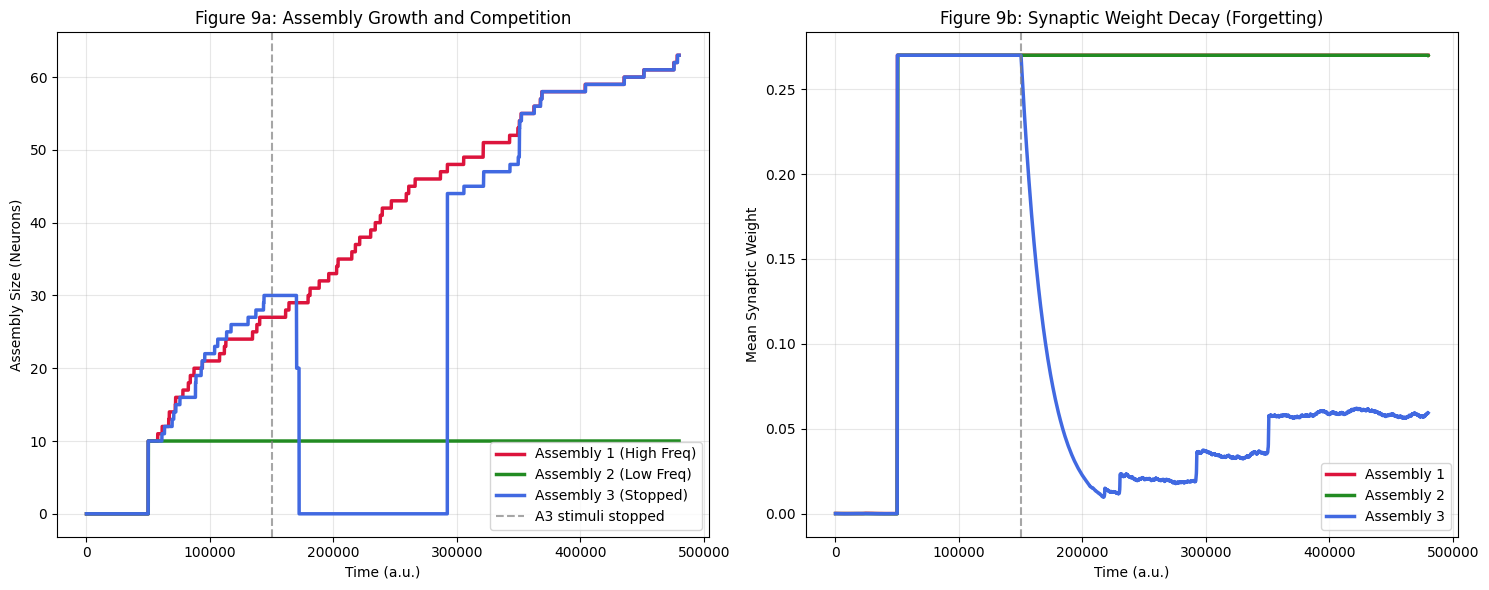

In [24]:
plot_competition_results(results_week5)

In [ ]:
# final version with survival threshold

def plot_competition_results(results, save_path=None):
    """
    Plot Figure 9: Memory Competition and Forgetting (Illusion Fixed).
    """
    times = results['times']
    weights = results['weights']
    
    # --- THE FIX: Apply a Survival Threshold ---
    # We convert the sizes to numpy arrays first
    raw_size_a1 = np.array(results['sizes']['A1'])
    raw_size_a2 = np.array(results['sizes']['A2'])
    raw_size_a3 = np.array(results['sizes']['A3'])
    
    # If the internal core weight drops below 0.1, the memory is considered "dead"
    # and its size is forced to 0. Otherwise, we plot its actual size.
    survival_threshold = 0.1
    
    # np.where works like an IF statement: IF weight > 0.1, keep the size, ELSE set to 0.
    size_a1_fixed = np.where(np.array(weights['A1']) > survival_threshold, raw_size_a1, 0)
    size_a2_fixed = np.where(np.array(weights['A2']) > survival_threshold, raw_size_a2, 0)
    size_a3_fixed = np.where(np.array(weights['A3']) > survival_threshold, raw_size_a3, 0)

    # -------------------------------------------
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    color_a1 = 'crimson'      
    color_a2 = 'forestgreen'  
    color_a3 = 'royalblue'    
    
    # --- Panel 1: Assembly Sizes ---
    ax1 = axes[0]
    # Use the new "fixed" size arrays here
    ax1.plot(times, size_a1_fixed, label='Assembly 1 (High Freq)', color=color_a1, linewidth=2.5)
    ax1.plot(times, size_a2_fixed, label='Assembly 2 (Low Freq)', color=color_a2, linewidth=2.5)
    ax1.plot(times, size_a3_fixed, label='Assembly 3 (Stopped)', color=color_a3, linewidth=2.5)
    
    ax1.set_xlabel('Time (a.u.)')
    ax1.set_ylabel('Assembly Size (Neurons)')
    ax1.set_title('Figure 9a: Assembly Growth and Competition')
    ax1.axvline(x=150000, color='gray', linestyle='--', alpha=0.7, label='A3 stimuli stopped')
    
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # --- Panel 2: Synaptic Strength (Weights) ---
    ax2 = axes[1]
    ax2.plot(times, weights['A1'], label='Assembly 1', color=color_a1, linewidth=2.5)
    ax2.plot(times, weights['A2'], label='Assembly 2', color=color_a2, linewidth=2.5)
    ax2.plot(times, weights['A3'], label='Assembly 3', color=color_a3, linewidth=2.5)
    
    ax2.set_xlabel('Time (a.u.)')
    ax2.set_ylabel('Mean Synaptic Weight')
    ax2.set_title('Figure 9b: Synaptic Weight Decay (Forgetting)')
    ax2.axvline(x=150000, color='gray', linestyle='--', alpha=0.7)
    
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
        
    plt.show()
    

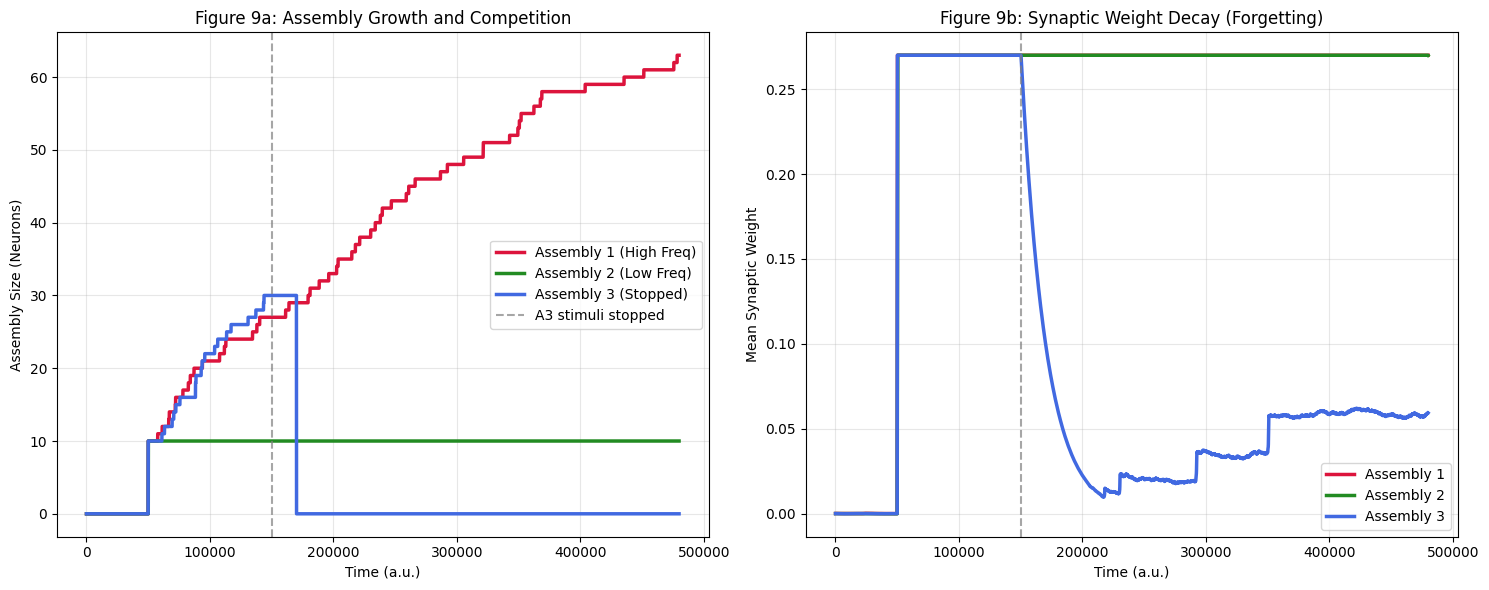

In [22]:
plot_competition_results(results_week5)

## Week 5 (extended) — Two-phase: formation → competition

Splits the experiment cleanly into two phases: **Phase 1** grows the assemblies from scratch, and
**Phase 2** takes that learned weight matrix and lets the memories compete. This isolates *what was
formed* from *what survives competition*.


### Phase 1 — Assembly formation

Grows the assemblies from a blank weight matrix and tracks each one's size over time.


In [20]:
# PHASE 1: ASSEMBLY FORMATION
# stimulating 3 assemblies at different times, but same frequency
# we want them to evolve from 10 neurons to 30 neurons each, without interfering with each other

def run_competition_phase1(total_time=120000):
# our longest stimulation time
# reason: decay is much slower than growth (cut A3 off at t=150000, had to give time afterwards to gradually wear down)

    print("Phase 1: Assembly formation")
    
    # --- Setup Frequencies ---
    tsep1 = tsep2 = tsep3 = 30   # All assemblies: Frequent   
    

    # Calculate the exact number of stimulations to fit within the time limits.
    # We subtract 50000 because the first stimulation starts at t=50000.
    n_stims1 = n_stims2 = n_stims3 = int((total_time - 50000) / tsep1)
    

    
    np.random.seed(42) # Fixed seed for reproducible competition
    
    # --- 1. Initialize 3 Orthogonal Assemblies ---
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    # Slice the shuffled list to ensure the assemblies share zero neurons
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[10:20]
    assm3 = all_neurons[20:30]
    
# --- 2. Independent Stimulation Schedules  ---
# We add a 10 a.u. delay between each assembly's start time to prevent 
# them from firing at the exact same millisecond and fusing together.

    # A1 starts at 50.000
    tonsets1 = np.array([50000 + i * tsep1 for i in range(n_stims1)])
    toffsets1 = tonsets1 + 5
    
    # A2 starts at 50.010
    tonsets2 = np.array([50010 + i * tsep2 for i in range(n_stims2)])
    toffsets2 = tonsets2 + 5
    
    # A3 starts at 50.020
    tonsets3 = np.array([50020 + i * tsep3 for i in range(n_stims3)])
    toffsets3 = tonsets3 + 5
    
    # --- State Variables ---
    W = np.zeros((N, N))   # Weight matrix
    r = np.zeros(N)        # Firing rates
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N) # Running mean firing rate
    mean_rate_initialized = False
    
    # --- Storage Arrays ---
    times = []
    sizes = {'A1': [], 'A2': [], 'A3': []}
    weights = {'A1': [], 'A2': [], 'A3': []}
    
    # --- Simulation Loop ---
    t = 0
    step = 0
    record_every = 1000 # Save data every 1000 steps to save memory

    
    while t < total_time:
        # Reset external input to zero for this timestep
        ext_input = np.zeros(N)
        
        # Check if current time 't' falls within any stimulation window.
        # If yes, apply current (1.0) to those specific neurons.
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
        if np.any((tonsets3 <= t) & (toffsets3 > t)):
            ext_input[assm3] = 1.0
            
        # Compute input with normalization scaling factors
        # to keep network stable
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)

        # Compute total input (weights * rates + external input) * scaling factor    
        h = (W @ r + ext_input) * SF
        
        # Update firing rates using sigmoid transfer function
        noise = C_noise * np.random.randn(N) # Add background noise for accidental recruitment
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        
        # Update threshold
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        # ------- Learning phase -------
        if step > 10:  # Wait a few steps for the network to stabilize
            # calculate the running mean of firing rates
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            

            # Apply Hebbian Learning: Learning Rate (LR) minus Forgetting Factor (beta)
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            # Keep weights within physical boundaries [Wmin, Wmax]
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            # Remove self-connections (neurons cannot connect to themselves)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        # ---------- Record Data -----------
        if step % record_every == 0 and step > 10:
            times.append(t)
            
            # Calculate and save the current size of each assembly            
            sizes['A1'].append(get_assembly_size(W, assm1))
            sizes['A2'].append(get_assembly_size(W, assm2))
            sizes['A3'].append(get_assembly_size(W, assm3))
            
            # Record mean weights
            weights['A1'].append(np.mean(W[np.ix_(assm1, assm1)]))
            weights['A2'].append(np.mean(W[np.ix_(assm2, assm2)]))
            weights['A3'].append(np.mean(W[np.ix_(assm3, assm3)]))

        # Move variables to the next timestep    
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    # --- Results Dictionary ---
    results = {
        'times': np.array(times),
        'sizes': sizes,
        'weights': weights,
        'final_W': W,
        'assemblies': {'A1': assm1, 'A2': assm2, 'A3': assm3}
    }
    
    return results 


Starting simulation: phase 1 ...
Phase 1: Assembly formation
Simulation completed!


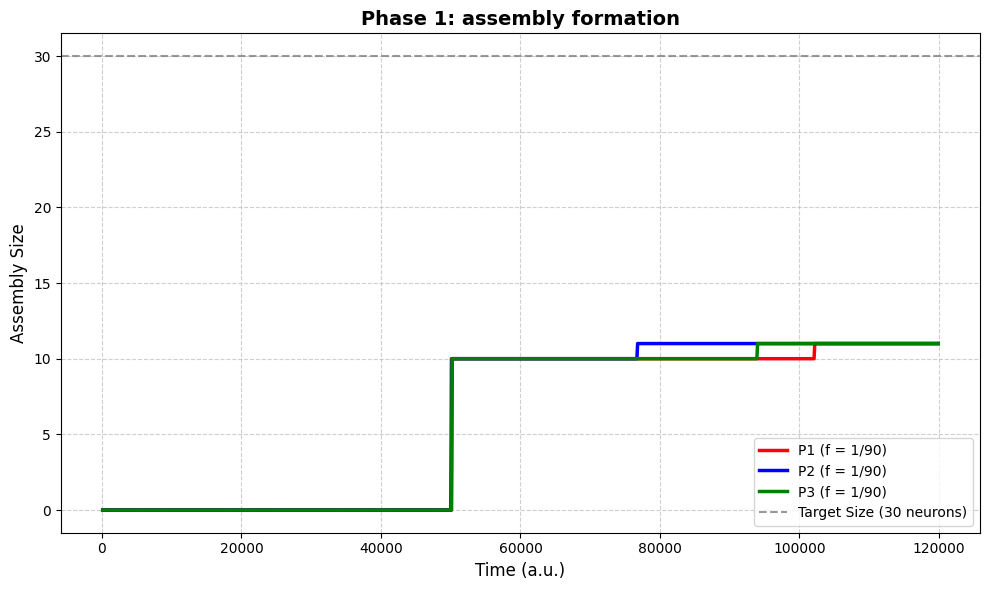

In [17]:
print("Starting simulation: phase 1 ...")
phase1_results = run_competition_phase1(total_time=120000)
print("Simulation completed!")

# 3. Plotting the Time-Series Graph
plt.figure(figsize=(10, 6))

# Plot the sizes of the three assemblies over time
plt.plot(phase1_results['times'], phase1_results['sizes']['A1'], label='P1 (f = 1/90)', color='red', linewidth=2.5)
plt.plot(phase1_results['times'], phase1_results['sizes']['A2'], label='P2 (f = 1/90)', color='blue', linewidth=2.5)
plt.plot(phase1_results['times'], phase1_results['sizes']['A3'], label='P3 (f = 1/90)', color='green', linewidth=2.5)

# Formatting the graph
plt.title('Phase 1: assembly formation', fontsize=14, fontweight='bold')
plt.xlabel('Time (a.u.)', fontsize=12)
plt.ylabel('Assembly Size', fontsize=12)

# Add a target line to see if they successfully reach ~30 neurons
plt.axhline(30, color='gray', linestyle='--', alpha=0.8, label='Target Size (30 neurons)')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [21]:
def plot_assembly_evolution(results, title="Assembly formation over time", 
                            label_p1="P1", label_p2="P2", label_p3="P3", 
                            target_size=30, phase_divider=None):
    """
    Plots the growth of three assemblies over time.
    """
    plt.figure(figsize=(10, 6))

    # Plot the sizes of the three assemblies over time
    plt.plot(results['times'], results['sizes']['A1'], label=label_p1, color='red', linewidth=2.5)
    plt.plot(results['times'], results['sizes']['A2'], label=label_p2, color='blue', linewidth=2.5)
    plt.plot(results['times'], results['sizes']['A3'], label=label_p3, color='green', linewidth=2.5)

    # Formatting the graph
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Time (a.u.)', fontsize=12)
    plt.ylabel('Assembly size', fontsize=12)

    # Add a target line 
    if target_size:
        plt.axhline(target_size, color='gray', linestyle='--', alpha=0.8, label=f'Target Size ({target_size})')
        
    # Optional: Add a vertical line for phase transitions (You will need this for Phase 2!)
    if phase_divider:
        plt.axvline(x=phase_divider, color='black', linestyle=':', linewidth=2, label='Phase 2 Starts')

    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Moved legend to upper left so it doesn't block the lines as they grow
    plt.legend(loc='upper left', fontsize=10) 
    plt.tight_layout()
    plt.show()

Starting simulation: phase 1 ...
Phase 1: Assembly formation
Simulation completed!


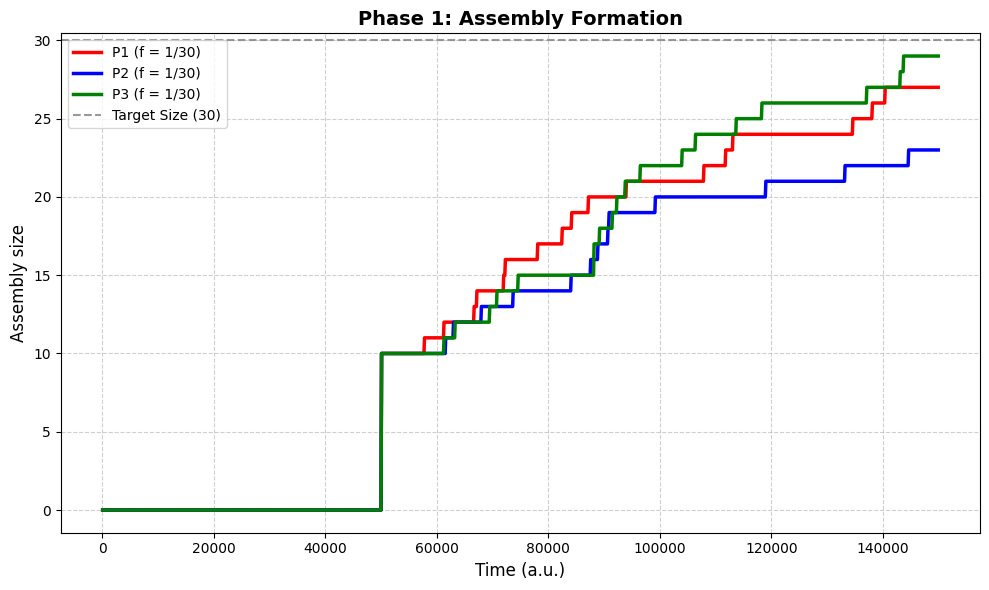

In [ ]:
# raised the frequency to 1/30 to see if they can reach 30 neurons each in a reasonable time
# lowered time to 150000 to speed up the simulation

print("Starting simulation: phase 1 ...")
phase1_results = run_competition_phase1(total_time=150000)
print("Simulation completed!")

plot_assembly_evolution(
    results=phase1_results, 
    title="Phase 1: Assembly Formation",
    label_p1="P1 (f = 1/30)",
    label_p2="P2 (f = 1/30)",
    label_p3="P3 (f = 1/30)"
)


Starting simulation: phase 1 ...
Phase 1: Assembly formation
Simulation completed!


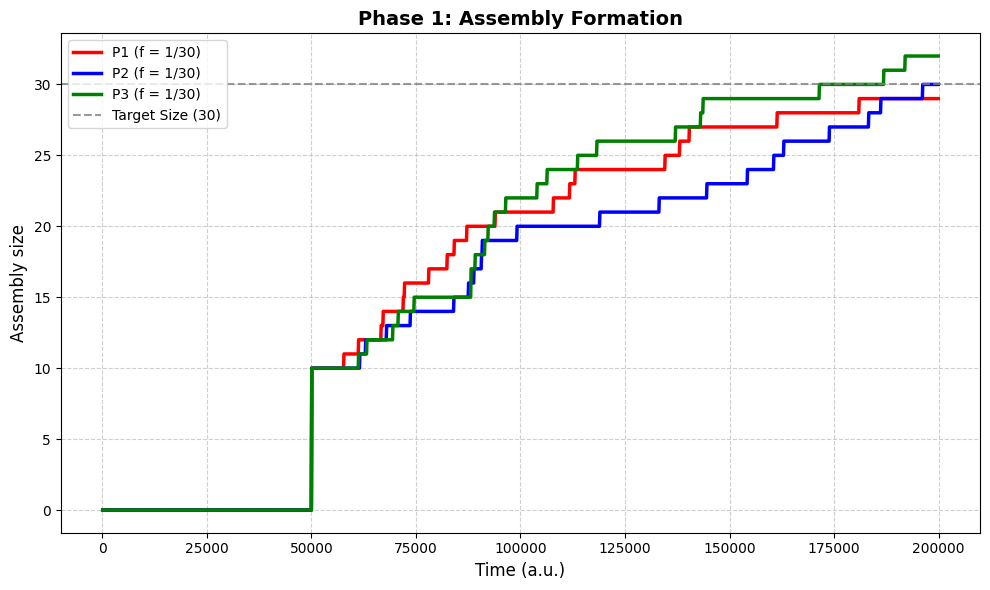

In [25]:
# raising time to 200000 to see if they can reach 30 neurons each in a reasonable time


print("Starting simulation: phase 1 ...")
phase1_results = run_competition_phase1(total_time=200000)
print("Simulation completed!")

plot_assembly_evolution(
    results=phase1_results, 
    title="Phase 1: Assembly Formation",
    label_p1="P1 (f = 1/30)",
    label_p2="P2 (f = 1/30)",
    label_p3="P3 (f = 1/30)"
)

In [27]:
# Grab the last recorded size, or print 0 if nothing was recorded yet
final_a1 = phase1_results['sizes']['A1'][-1] if phase1_results['sizes']['A1'] else 0
final_a2 = phase1_results['sizes']['A2'][-1] if phase1_results['sizes']['A2'] else 0
final_a3 = phase1_results['sizes']['A3'][-1] if phase1_results['sizes']['A3'] else 0

print(f"Final size of Assembly 1: {final_a1}")
print(f"Final size of Assembly 2: {final_a2}")
print(f"Final size of Assembly 3: {final_a3}")

Final size of Assembly 1: 29
Final size of Assembly 2: 30
Final size of Assembly 3: 32


In [28]:
# what happens if they start all together at the same time? will they interfere with each other and not reach 30 neurons each?

def run_competition_phase1_nodelay(total_time=120000):

    print("Phase 1: Assembly formation - no delay")
    
    # --- Setup Frequencies ---
    tsep1 = tsep2 = tsep3 = 30   # All assemblies: Frequent   
    

    # Calculate the exact number of stimulations to fit within the time limits.
    # We subtract 50000 because the first stimulation starts at t=50000.
    n_stims1 = n_stims2 = n_stims3 = int((total_time - 50000) / tsep1)
    

    
    np.random.seed(42) # Fixed seed for reproducible competition
    
    # --- 1. Initialize 3 Orthogonal Assemblies ---
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    # Slice the shuffled list to ensure the assemblies share zero neurons
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[10:20]
    assm3 = all_neurons[20:30]
    
# --- 2. CHANGED Stimulation Schedules  ---
# We removed a 10 a.u. delay between each assembly's start time 

    # A1, A2 and A3 starts all at 50.000
    tonsets1 = np.array([50000 + i * tsep1 for i in range(n_stims1)])
    toffsets1 = tonsets1 + 5
    
    
    tonsets2 = np.array([50000 + i * tsep2 for i in range(n_stims2)])
    toffsets2 = tonsets2 + 5
    
    
    tonsets3 = np.array([50000 + i * tsep3 for i in range(n_stims3)])
    toffsets3 = tonsets3 + 5
    
    # --- State Variables ---
    W = np.zeros((N, N))   # Weight matrix
    r = np.zeros(N)        # Firing rates
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N) # Running mean firing rate
    mean_rate_initialized = False
    
    # --- Storage Arrays ---
    times = []
    sizes = {'A1': [], 'A2': [], 'A3': []}
    weights = {'A1': [], 'A2': [], 'A3': []}
    
    # --- Simulation Loop ---
    t = 0
    step = 0
    record_every = 1000 # Save data every 1000 steps to save memory

    
    while t < total_time:
        # Reset external input to zero for this timestep
        ext_input = np.zeros(N)
        
        # Check if current time 't' falls within any stimulation window.
        # If yes, apply current (1.0) to those specific neurons.
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
        if np.any((tonsets3 <= t) & (toffsets3 > t)):
            ext_input[assm3] = 1.0
            
        # Compute input with normalization scaling factors
        # to keep network stable
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)

        # Compute total input (weights * rates + external input) * scaling factor    
        h = (W @ r + ext_input) * SF
        
        # Update firing rates using sigmoid transfer function
        noise = C_noise * np.random.randn(N) # Add background noise for accidental recruitment
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        
        # Update threshold
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        # ------- Learning phase -------
        if step > 10:  # Wait a few steps for the network to stabilize
            # calculate the running mean of firing rates
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            

            # Apply Hebbian Learning: Learning Rate (LR) minus Forgetting Factor (beta)
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            # Keep weights within physical boundaries [Wmin, Wmax]
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            # Remove self-connections (neurons cannot connect to themselves)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        # ---------- Record Data -----------
        if step % record_every == 0 and step > 10:
            times.append(t)
            
            # Calculate and save the current size of each assembly            
            sizes['A1'].append(get_assembly_size(W, assm1))
            sizes['A2'].append(get_assembly_size(W, assm2))
            sizes['A3'].append(get_assembly_size(W, assm3))
            
            # Record mean weights
            weights['A1'].append(np.mean(W[np.ix_(assm1, assm1)]))
            weights['A2'].append(np.mean(W[np.ix_(assm2, assm2)]))
            weights['A3'].append(np.mean(W[np.ix_(assm3, assm3)]))

        # Move variables to the next timestep    
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    # --- Results Dictionary ---
    results = {
        'times': np.array(times),
        'sizes': sizes,
        'weights': weights,
        'final_W': W,
        'assemblies': {'A1': assm1, 'A2': assm2, 'A3': assm3}
    }
    
    return results 


Starting simulation: phase 1, with no delay...
Phase 1: Assembly formation - no delay
Simulation completed!


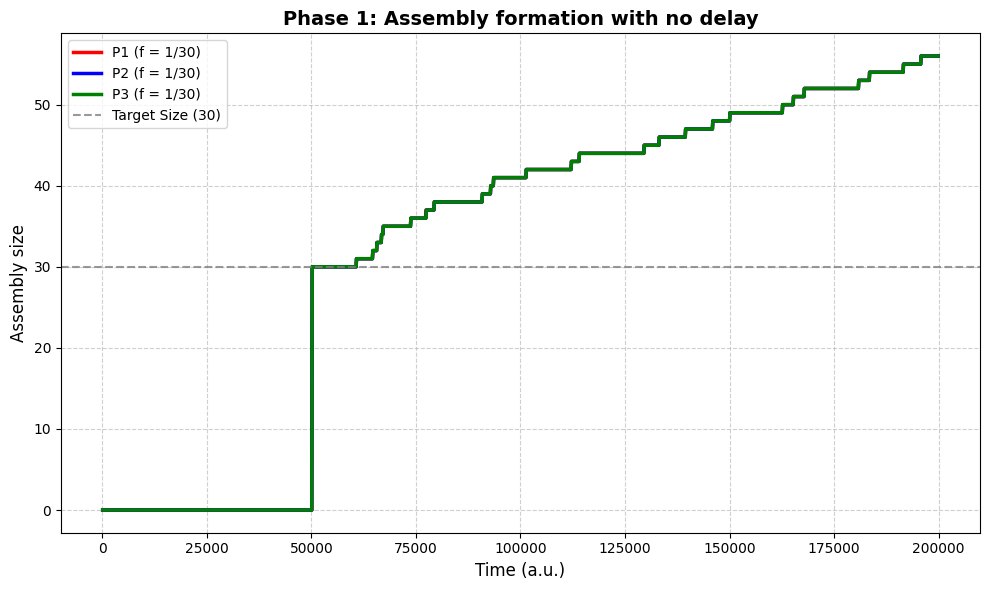

In [34]:
print("Starting simulation: phase 1, with no delay...")
phase1_results_nodelay = run_competition_phase1_nodelay(total_time=200000)
print("Simulation completed!")

plot_assembly_evolution(
    results=phase1_results_nodelay, 
    title="Phase 1: Assembly formation with no delay",
    label_p1="P1 (f = 1/30)",
    label_p2="P2 (f = 1/30)",
    label_p3="P3 (f = 1/30)"
)



In [33]:
final_a1_nodelay = phase1_results_nodelay['sizes']['A1'][-1] if phase1_results_nodelay['sizes']['A1'] else 0
final_a2_nodelay = phase1_results_nodelay['sizes']['A2'][-1] if phase1_results_nodelay['sizes']['A2'] else 0
final_a3_nodelay = phase1_results_nodelay['sizes']['A3'][-1] if phase1_results_nodelay['sizes']['A3'] else 0

print(f"Final size of Assembly 1: {final_a1_nodelay}")
print(f"Final size of Assembly 2: {final_a2_nodelay}")
print(f"Final size of Assembly 3: {final_a3_nodelay}")

Final size of Assembly 1: 56
Final size of Assembly 2: 56
Final size of Assembly 3: 56


### Phase 2 — Memory competition

Loads the weight matrix and assemblies produced by Phase 1, then runs competition to see which
memories are reinforced and which fade.


In [35]:
def run_competition_phase2(W_init, assemblies, total_time=200000):
    print("Phase 2: Assembly Evolution (Competition)")
    
    # --- Unpack the Phase 1 Brain ---
    assm1 = assemblies['A1']
    assm2 = assemblies['A2']
    assm3 = assemblies['A3']
    
    # --- Setup NEW Frequencies ---
    tsep1 = 60   # A1 is Frequent
    tsep2 = 120  # A2 is Rare
    # A3 gets nothing!
    
    n_stims1 = int(total_time / tsep1)
    n_stims2 = int(total_time / tsep2)
    
    np.random.seed(42) # Keep the noise consistent
    
    # --- Staggered Stimulation Schedules ---
    # A1 starts at 0
    tonsets1 = np.array([0 + i * tsep1 for i in range(n_stims1)])
    toffsets1 = tonsets1 + 5
    
    # A2 starts at 10 to prevent overlap
    tonsets2 = np.array([10 + i * tsep2 for i in range(n_stims2)])
    toffsets2 = tonsets2 + 5
    
    # --- State Variables ---
    W = W_init.copy()  # CRITICAL: We start with the fully grown assemblies!
    r = np.zeros(N)    # Reset firing rates for the new phase
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    # --- Storage Arrays ---
    times = []
    sizes = {'A1': [], 'A2': [], 'A3': []}
    
    # --- Simulation Loop ---
    t = 0
    step = 0
    record_every = 1000 
    
    while t < total_time:
        ext_input = np.zeros(N)
        
        # Apply current only to A1 and A2. A3 is abandoned!
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
            
        # Compute input with normalization
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)

        h = (W @ r + ext_input) * SF
        
        # Update firing rates 
        noise = C_noise * np.random.randn(N) 
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        
        # Update threshold
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        # ------- Learning phase -------
        if step > 10:  
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            # Hebbian Learning
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        # ---------- Record Data -----------
        if step % record_every == 0 and step > 10:
            times.append(t)
            sizes['A1'].append(get_assembly_size(W, assm1))
            sizes['A2'].append(get_assembly_size(W, assm2))
            sizes['A3'].append(get_assembly_size(W, assm3))

        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    results = {
        'times': np.array(times),
        'sizes': sizes,
        'final_W': W
    }
    
    return results

Starting Phase 2 competition... 
Phase 2: Assembly Evolution (Competition)
Phase 2 complete! Generating graph...


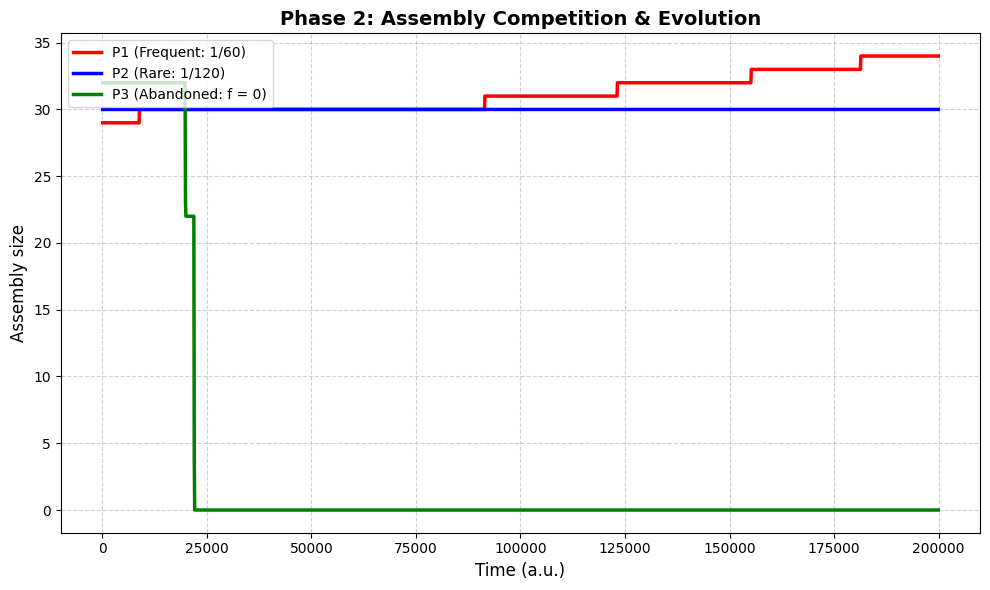

In [36]:
# 1. Run the competition, passing in the final matrix and assemblies from Phase 1
print("Starting Phase 2 competition... ")
phase2_results = run_competition_phase2(
    W_init=phase1_results['final_W'], 
    assemblies=phase1_results['assemblies'],
    total_time=200000
)
print("Phase 2 complete! Generating graph...")

# 2. Draw the Graph
plot_assembly_evolution(
    results=phase2_results, 
    title="Phase 2: Assembly Competition & Evolution",
    label_p1="P1 (Frequent: 1/60)",
    label_p2="P2 (Rare: 1/120)",
    label_p3="P3 (Abandoned: f = 0)",
    target_size=None # We turn off the 30-neuron target line here
)

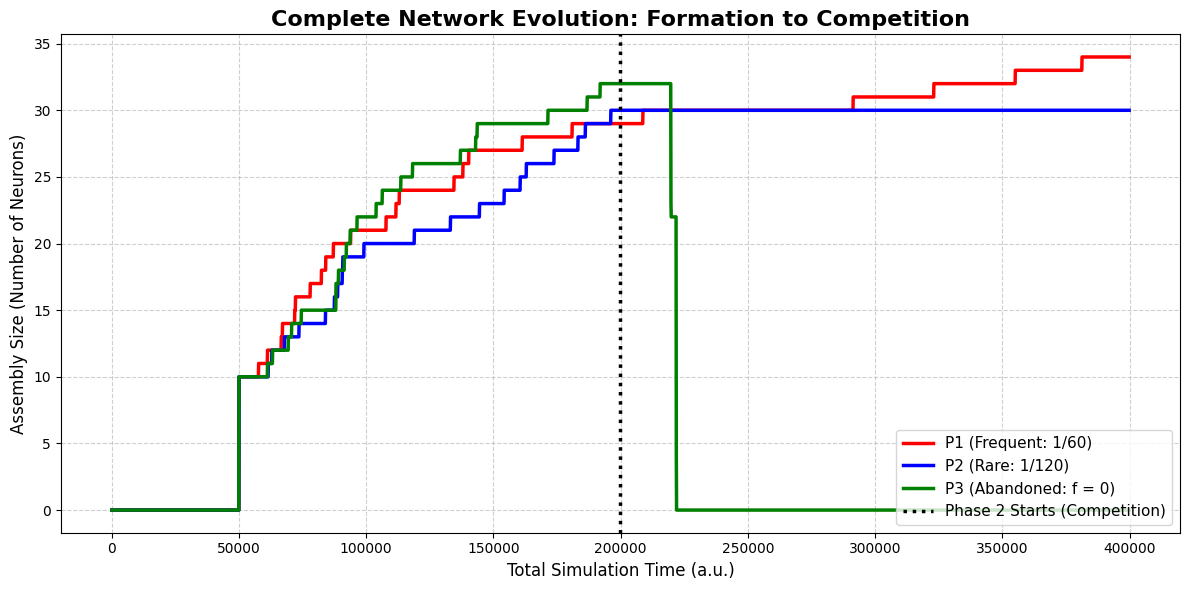

In [37]:
def plot_full_evolution(phase1_res, phase2_res):
    """
    Stitches Phase 1 and Phase 2 data together for a continuous timeline.
    """
    # 1. Stitch the timelines together
    # Offset Phase 2 times by the very last time step of Phase 1
    t_offset = phase1_res['times'][-1] 
    combined_times = np.concatenate([phase1_res['times'], phase2_res['times'] + t_offset])
    
    # 2. Stitch the sizes together
    p1_combined = np.concatenate([phase1_res['sizes']['A1'], phase2_res['sizes']['A1']])
    p2_combined = np.concatenate([phase1_res['sizes']['A2'], phase2_res['sizes']['A2']])
    p3_combined = np.concatenate([phase1_res['sizes']['A3'], phase2_res['sizes']['A3']])
    
    # 3. Draw the master graph
    plt.figure(figsize=(12, 6)) # Made it slightly wider for the long timeline
    
    plt.plot(combined_times, p1_combined, label='P1 (Frequent: 1/60)', color='red', linewidth=2.5)
    plt.plot(combined_times, p2_combined, label='P2 (Rare: 1/120)', color='blue', linewidth=2.5)
    plt.plot(combined_times, p3_combined, label='P3 (Abandoned: f = 0)', color='green', linewidth=2.5)
    
    # 4. Add the Phase Divider
    plt.axvline(x=t_offset, color='black', linestyle=':', linewidth=2.5, 
                label='Phase 2 Starts (Competition)')
    
    # 5. Formatting
    plt.title('Complete Network Evolution: Formation to Competition', fontsize=16, fontweight='bold')
    plt.xlabel('Total Simulation Time (a.u.)', fontsize=12)
    plt.ylabel('Assembly Size (Number of Neurons)', fontsize=12)
    
    # Move legend to bottom right as requested
    plt.legend(loc='lower right', fontsize=11)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Run the function using your saved data
plot_full_evolution(phase1_results, phase2_results)

In [38]:
final_a1_evolution = phase2_results['sizes']['A1'][-1] if phase2_results['sizes']['A1'] else 0
final_a2_evolution = phase2_results['sizes']['A2'][-1] if phase2_results['sizes']['A2'] else 0
final_a3_evolution = phase2_results['sizes']['A3'][-1] if phase2_results['sizes']['A3'] else 0

print(f"Final size of Assembly 1: {final_a1_evolution}")
print(f"Final size of Assembly 2: {final_a2_evolution}")
print(f"Final size of Assembly 3: {final_a3_evolution}")

Final size of Assembly 1: 34
Final size of Assembly 2: 30
Final size of Assembly 3: 0


Starting Extended Phase 2 competition... (This will take a few minutes!)
Phase 2: Assembly Evolution (Competition)
Extended Phase 2 complete! Generating graph...


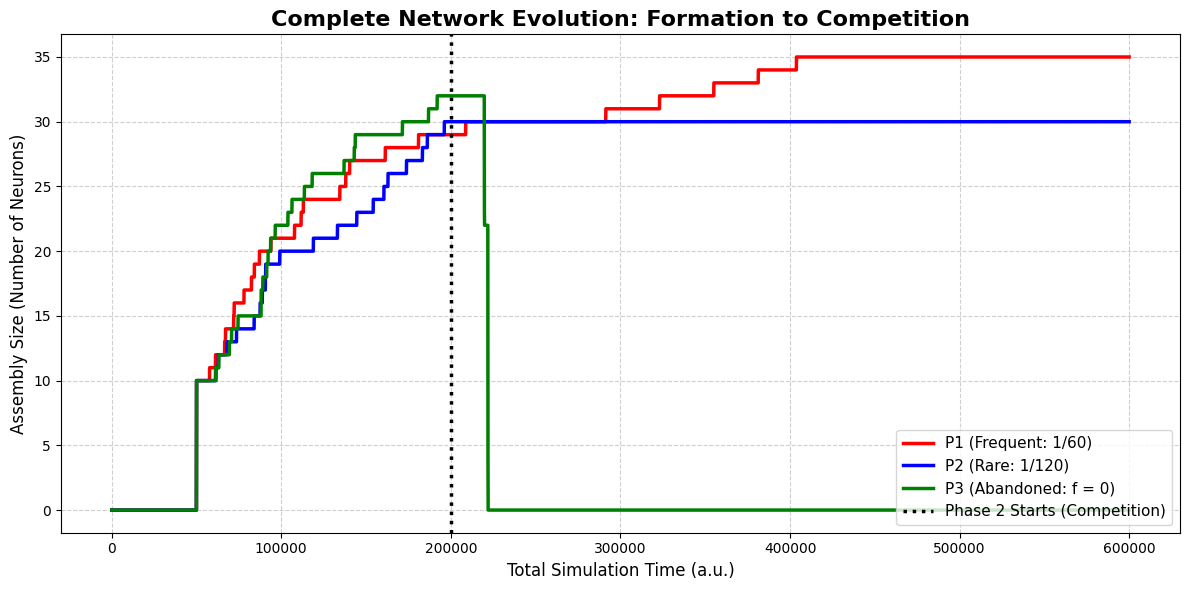

In [39]:
# what happens if we double sim time?
# 1. Run the Extended Phase 2
print("Starting Extended Phase 2 competition... (This will take a few minutes!)")
extended_phase2_results = run_competition_phase2(
    W_init=phase1_results['final_W'], 
    assemblies=phase1_results['assemblies'],
    total_time=400000  # <--- Time doubled!
)
print("Extended Phase 2 complete! Generating graph...")

# 2. Draw the graph with the extended data
plot_full_evolution(phase1_results, extended_phase2_results)

In [ ]:
# we are interested now in the mean weights from P1 to the other populations, to see if they are decaying or not

def run_competition_phase2_fig9B(W_init, assemblies, total_time=400000):
    print("Running Phase 2 (Fig 9B Tracking)...")
    
    assm1 = assemblies['A1']
    assm2 = assemblies['A2']
    assm3 = assemblies['A3']
    
    # Identify the Background Neurons (the ones not in any core assembly)
    all_core = np.concatenate([assm1, assm2, assm3])
    bg_neurons = np.setdiff1d(np.arange(N), all_core)
    
    tsep1 = 60   
    tsep2 = 120  
    n_stims1 = int(total_time / tsep1)
    n_stims2 = int(total_time / tsep2)
    
    np.random.seed(42) 
    
    tonsets1 = np.array([0 + i * tsep1 for i in range(n_stims1)])
    toffsets1 = tonsets1 + 5
    tonsets2 = np.array([10 + i * tsep2 for i in range(n_stims2)])
    toffsets2 = tonsets2 + 5
    
    W = W_init.copy()  
    r = np.zeros(N)    
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    times = []
    # New Storage Arrays for Fig 9B
    weights_p1_to_bg = []
    weights_p1_to_p2 = []
    weights_p1_to_p3 = []
    
    t = 0
    step = 0
    record_every = 1000 
    
    while t < total_time:
        ext_input = np.zeros(N)
        if np.any((tonsets1 <= t) & (toffsets1 > t)): ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)): ext_input[assm2] = 1.0
            
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)

        h = (W @ r + ext_input) * SF
        
        noise = C_noise * np.random.randn(N) 
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        if step > 10:  
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights: W = np.clip(W, Wmin, Wmax)
            if not autoconnections: np.fill_diagonal(W, 0.0)
                
        # --- The New Fig 9B Recording Block ---
        if step % record_every == 0 and step > 10:
            times.append(t)
            # Calculate the average weight from P1 to the three target populations
            weights_p1_to_bg.append(np.mean(W[np.ix_(bg_neurons, assm1)]))
            weights_p1_to_p2.append(np.mean(W[np.ix_(assm2, assm1)]))
            weights_p1_to_p3.append(np.mean(W[np.ix_(assm3, assm1)]))

        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    return {
        'times': np.array(times),
        'p1_to_bg': np.array(weights_p1_to_bg),
        'p1_to_p2': np.array(weights_p1_to_p2),
        'p1_to_p3': np.array(weights_p1_to_p3)
    }

Running Phase 2 (Fig 9B Tracking)...


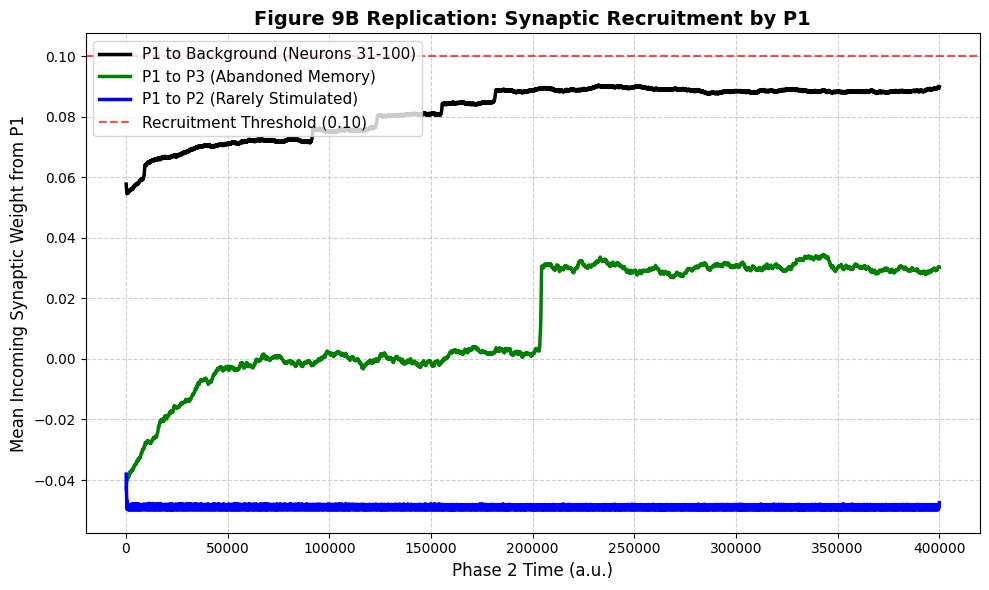

In [41]:
# 1. Run the specialized simulation
fig9b_results = run_competition_phase2_fig9B(
    W_init=phase1_results['final_W'], 
    assemblies=phase1_results['assemblies'],
    total_time=400000 
)

# 2. Draw Figure 9B
plt.figure(figsize=(10, 6))

plt.plot(fig9b_results['times'], fig9b_results['p1_to_bg'], label='P1 to Background (Neurons 31-100)', color='black', linewidth=2.5)
plt.plot(fig9b_results['times'], fig9b_results['p1_to_p3'], label='P1 to P3 (Abandoned Memory)', color='green', linewidth=2.5)
plt.plot(fig9b_results['times'], fig9b_results['p1_to_p2'], label='P1 to P2 (Rarely Stimulated)', color='blue', linewidth=2.5)

# Add our recruitment threshold to see exactly when neurons officially "join" P1
plt.axhline(0.10, color='red', linestyle='--', alpha=0.7, label='Recruitment Threshold (0.10)')

# Formatting
plt.title('Figure 9B Replication: Synaptic Recruitment by P1', fontsize=14, fontweight='bold')
plt.xlabel('Phase 2 Time (a.u.)', fontsize=12)
plt.ylabel('Mean Incoming Synaptic Weight from P1', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

## Week 6 — Overlapping memories

When two assemblies are co-presented, their cross-connections can potentiate and the memories start
to share neurons. This section explores when that overlap appears and how strong it gets. *cf. Fig. 9.*


In [ ]:
def run_overlap_experiment(total_time=200000):
    """
    Creates overlapping assemblies by weakening synaptic normalization 
    and using rapid alternating stimulation.
    """
    print("Attempt 1: overlapping assemblies")
    print("Parameters changed: Factor_SW = 0.15, no overlap neurons, no overlap time: A1 fires for 5 a.u. before A2")
    
    # --- 1. Modify Normalization (The Extension Requirement) ---
    global Factor_SW 
    original_Factor_SW = Factor_SW
    Factor_SW = original_Factor_SW * 0.15  # Weaken synaptic competition by 85%
    print(f"Synaptic Normalization weakened (Factor_SW: {Factor_SW})")
    

    # --- Setup Frequencies ---
    tsep = 30  # High frequency to force rapid growth
    n_stims = int((total_time - 50000) / tsep)
    
    np.random.seed(101) # Seed for reproducible overlap
    
    # Initialize 2 distinct core assemblies
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[10:20]
    
    # --- 2. Rapid Alternation Protocol ---
    # A1 fires for 5 a.u.
    tonsets1 = np.array([50000 + i * tsep for i in range(n_stims)])
    toffsets1 = tonsets1 + 5 
    
    # A2 fires IMMEDIATELY after A1 stops, catching the residual activity
    tonsets2 = np.array([50005 + i * tsep for i in range(n_stims)])
    toffsets2 = tonsets2 + 5
    
    # State Variables
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    t = 0
    step = 0
    
    # --- Simulation Loop ---
    print("Running simulation (this may take a minute)...")
    while t < total_time:
        ext_input = np.zeros(N)
        
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0

        # scaling implementation    
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)

        # total synaptic input entering each neuron's cell membrane    
        h = (W @ r + ext_input) * SF
        
        # --- FIRING RATE DYNAMICS (EULER INT) ----

        # random gaussian background noise for all neurons N
        noise = C_noise * np.random.randn(N)

        # passes the total input h minus the neuron's threshold
        # through a sigmoid
        # this yields how strongly the neurons wants to fire
        # capped at max rate r_max
        fi = r_max * sigmoid(h - threshold)

        # euler int step for firing rate
        # balancing tendency to decay back to a baseline rest state r0 
        # against new activation drive fi 
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise


        # euler int for intrinsic plasticity (adapting thresholds)
        # if a neuron fires heavily (r > r0), its threshold increases
        # making it harder to fire in the future
        # prevents hyper-excitability
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        

        # --- HEBBIAN LEARNING AND PLASTICITY

        # Learning
        if step > 10:
            # running avg of each neuron's firing rate 
            # over a sliding historical window meanWin
            # acts as a normal baseline activity for neuron
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            # subtracts running avg from current firing rate
            r_i_sub = r_new - mean_rate

            # hebbian learning with forgetting
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)


        # CLOCK ADVANCEMENT         
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    # Restore original normalization factor to avoid breaking other code
    Factor_SW = original_Factor_SW
    
    # --- Results ---
    results = {
        'final_W': W,
        'assm1': assm1,
        'assm2': assm2
    }
    print("Simulation complete!")
    return results

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_overlap_matrix(results, threshold=0.1):
    """
    Plots a dynamically reordered weight matrix to expose shared neurons.
    """
    W = results['final_W']
    assm1 = results['assm1']
    assm2 = results['assm2']
    
    # 1. Calculate incoming weights to determine recruitment
    incoming_A1 = np.mean(W[:, assm1], axis=1)
    incoming_A2 = np.mean(W[:, assm2], axis=1)
    
    # 2. Categorize all neurons based on who they connected to
    recruited_A1 = set(np.where(incoming_A1 > threshold)[0])
    recruited_A2 = set(np.where(incoming_A2 > threshold)[0])
    
    # Find the overlap (neurons that belong to BOTH assemblies)
    overlap = recruited_A1.intersection(recruited_A2)
    
    # Find neurons that belong exclusively to A1 or A2
    only_A1 = recruited_A1 - overlap
    only_A2 = recruited_A2 - overlap
    
    # Find the background neurons (connected to neither)
    all_neurons = set(np.arange(W.shape[0]))
    background = all_neurons - (recruited_A1 | recruited_A2)
    
    # 3. Create a strict sorting order to visualize the structures
    order = list(only_A1) + list(overlap) + list(only_A2) + list(background)
    W_ordered = W[np.ix_(order, order)]
    
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(W_ordered, cmap='RdBu_r', aspect='auto', vmin=-0.05, vmax=0.3)
    
    # Draw dividing lines to map out the different territories
    idx_A1_end = len(only_A1)
    idx_overlap_end = idx_A1_end + len(overlap)
    idx_A2_end = idx_overlap_end + len(only_A2)
    
    # Annotate the sections
    ax.axhline(y=idx_A1_end - 0.5, color='white', linestyle='--', alpha=0.8)
    ax.axhline(y=idx_overlap_end - 0.5, color='gold', linestyle='-', alpha=0.9, linewidth=2)
    ax.axhline(y=idx_A2_end - 0.5, color='white', linestyle='--', alpha=0.8)
    
    ax.axvline(x=idx_A1_end - 0.5, color='white', linestyle='--', alpha=0.8)
    ax.axvline(x=idx_overlap_end - 0.5, color='gold', linestyle='-', alpha=0.9, linewidth=2)
    ax.axvline(x=idx_A2_end - 0.5, color='white', linestyle='--', alpha=0.8)
    
    ax.set_title(f'Associated Memories (Overlap: {len(overlap)} shared neurons)')
    ax.set_xlabel('Sorted Neuron Index')
    ax.set_ylabel('Sorted Neuron Index')
    plt.colorbar(im, ax=ax, label='Synaptic Weight')
    
    print(f"Assembly 1 exclusive neurons: {len(only_A1)}")
    print(f"Shared (Overlap) neurons: {len(overlap)}")
    print(f"Assembly 2 exclusive neurons: {len(only_A2)}")
    
    plt.show()

WEEK 6: MEMORY ASSOCIATION (OVERLAPPING ASSEMBLIES)
Synaptic Normalization weakened (Factor_SW: 0.15)
Running simulation (this may take a minute)...
Simulation complete!
Assembly 1 exclusive neurons: 65
Shared (Overlap) neurons: 0
Assembly 2 exclusive neurons: 35


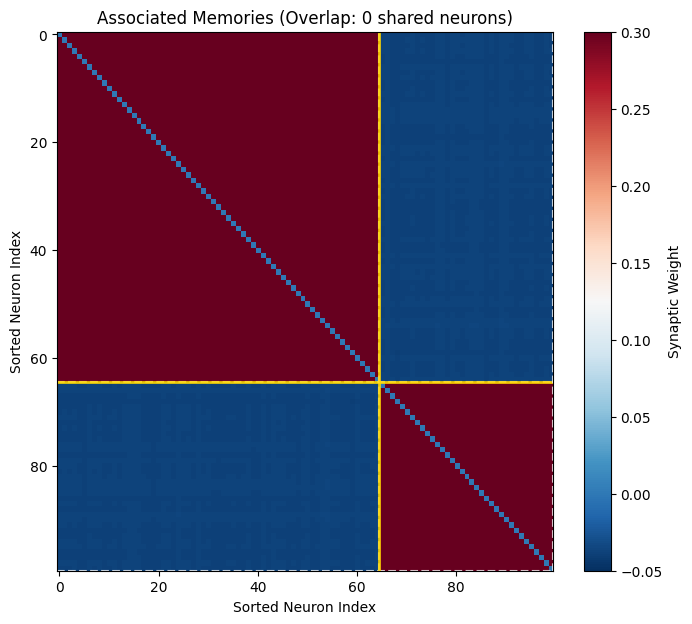

In [9]:
results_overlap = run_overlap_experiment(total_time=200000)
plot_overlap_matrix(results_overlap)

In [ ]:
def run_associated_memories(total_time=200000):
    """
    Week 6: Memory Association (Partial Temporal Overlap).
    Forces Hebbian co-activation by creating a 3 a.u. window where both 
    assemblies fire simultaneously, allowing background neurons to blend them.
    """
    print("Attempt 2: overlapping memories")
    print("Parameters changed: Factor_SW = 0.15, no overlap neurons, overlap time: 3 a.u.")
    
    
    # --- 1. Weaken Normalization to allow shared ownership ---
    global Factor_SW 
    original_Factor_SW = Factor_SW
    Factor_SW = original_Factor_SW * 0.15  # Weaken synaptic competition by 85%
    print(f"Synaptic Normalization weakened (Factor_SW: {Factor_SW})")
    
    tsep = 30  # High frequency to drive growth
    n_stims = int((total_time - 50000) / tsep)
    
    np.random.seed(101) # Keep seed identical to compare with the partition test
    
    # Initialize the same 2 distinct core assemblies of 10 neurons each
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[10:20]
    
    # --- 2. Partial Overlap Stimulation Protocol ---
    # Assembly 1 fires for 5 a.u.
    tonsets1 = np.array([50000 + i * tsep for i in range(n_stims)])
    toffsets1 = tonsets1 + 5 
    
    # Assembly 2 starts just 2 a.u. after Assembly 1 starts.
    # This creates a 3 a.u. window of simultaneous, synchronous firing.
    tonsets2 = np.array([50002 + i * tsep for i in range(n_stims)])
    toffsets2 = tonsets2 + 5
    
    # State Variables
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    t = 0
    step = 0
    
    # --- Simulation Loop ---
    print("Running partial overlap simulation...")
    while t < total_time:
        ext_input = np.zeros(N)
        
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
            
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)
            
        h = (W @ r + ext_input) * SF
        
        noise = C_noise * np.random.randn(N)
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        # Hebbian Learning
        if step > 10:
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    # Restore original normalization factor for network integrity
    Factor_SW = original_Factor_SW
    
    # --- Results ---
    results = {
        'final_W': W,
        'assm1': assm1,
        'assm2': assm2
    }
    print("Simulation complete!")
    return results

WEEK 6: SUCCESSFUL MEMORY ASSOCIATION (PARTIAL OVERLAP)
Synaptic Normalization weakened (Factor_SW: 0.15)
Running partial overlap simulation...
Simulation complete!
Assembly 1 exclusive neurons: 0
Shared (Overlap) neurons: 94
Assembly 2 exclusive neurons: 0


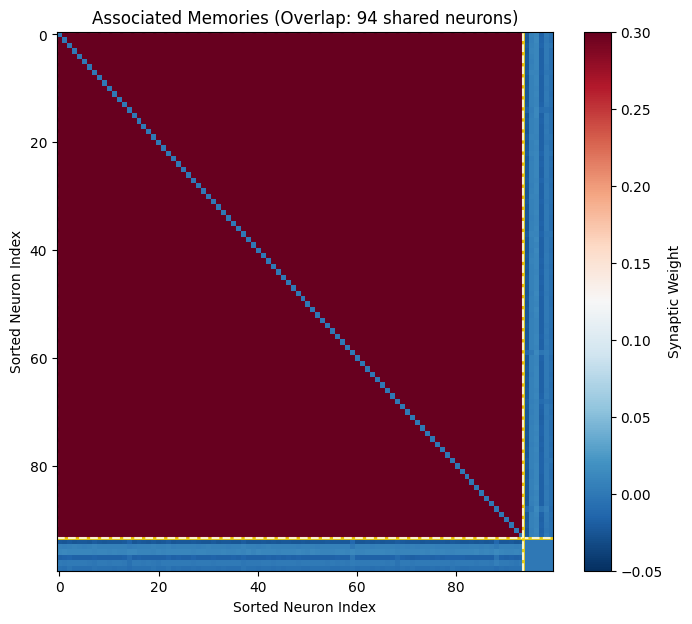

In [11]:
# 2. Run the New Partial Overlap Experiment (Your successful milestone endpoint)
results_association = run_associated_memories(total_time=200000)
plot_overlap_matrix(results_association)

In [ ]:
def run_tuned_association(total_time=200000):
    """
    Week 6: Memory Association (Fine-Tuned Overlap).
    Uses a minimal 1 a.u. co-activation window to build a shared bridge
    without causing total memory fusion.
    """
    print("Attempt 3: overlapping memories")
    print("Parameters changes: Factor_SW = 0.15, no overlap neurons, overlap time = 1 a.u.")
    
    
    global Factor_SW 
    original_Factor_SW = Factor_SW
    Factor_SW = original_Factor_SW * 0.15  
    print(f"Synaptic Normalization weakened (Factor_SW: {Factor_SW})")
    
    tsep = 30  
    n_stims = int((total_time - 50000) / tsep)
    
    np.random.seed(101) 
    
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[10:20]
    
    # --- 3. The "Goldilocks" Protocol ---
    # A1 fires for 5 a.u.
    tonsets1 = np.array([50000 + i * tsep for i in range(n_stims)])
    toffsets1 = tonsets1 + 5 
    
    # A2 starts exactly 4 a.u. after A1 starts.
    # This leaves a tiny 1 a.u. window of simultaneous firing.
    tonsets2 = np.array([50004 + i * tsep for i in range(n_stims)])
    toffsets2 = tonsets2 + 5
    
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    t = 0
    step = 0
    
    print("Running fine-tuned simulation...")
    while t < total_time:
        ext_input = np.zeros(N)
        
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
            
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)
            
        h = (W @ r + ext_input) * SF
        
        noise = C_noise * np.random.randn(N)
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        if step > 10:
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    Factor_SW = original_Factor_SW
    
    results = {
        'final_W': W,
        'assm1': assm1,
        'assm2': assm2
    }
    print("Simulation complete!")
    return results

WEEK 6: FINE-TUNED MEMORY ASSOCIATION
Synaptic Normalization weakened (Factor_SW: 0.15)
Running fine-tuned simulation...
Simulation complete!
Assembly 1 exclusive neurons: 0
Shared (Overlap) neurons: 93
Assembly 2 exclusive neurons: 0


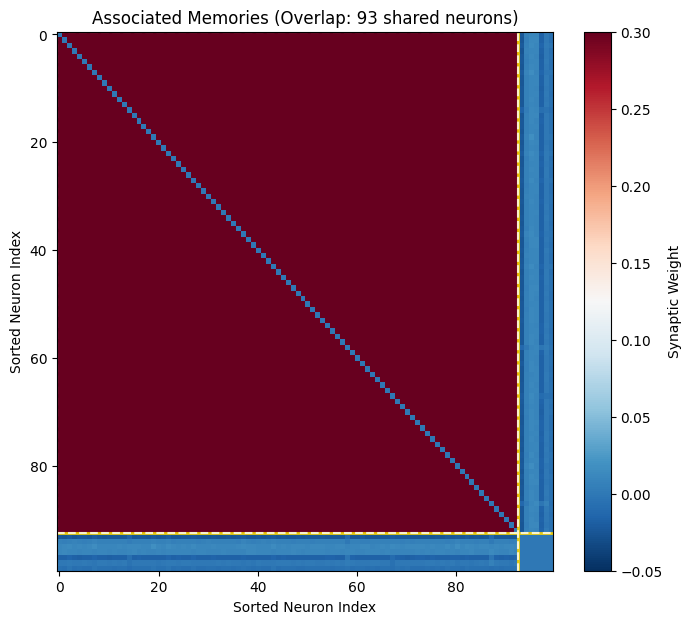

In [13]:
results_tuned = run_tuned_association()
plot_overlap_matrix(results_tuned)

In [14]:
def run_parameterized_association(sw_multiplier=0.5, offset=4, total_time=200000):
    """
    Week 6: Memory Association (Parameter Sweep).
    Allows easy tweaking of the normalization strength and temporal overlap.
    """
    print("="*70)
    print(f"WEEK 6: TESTING ASSOCIATION (SW_Multiplier: {sw_multiplier}, Offset: {offset})")
    print("="*70)
    
    global Factor_SW 
    original_Factor_SW = Factor_SW
    Factor_SW = original_Factor_SW * sw_multiplier  
    print(f"Synaptic Normalization set to {sw_multiplier * 100}% of original.")
    
    tsep = 30  
    n_stims = int((total_time - 50000) / tsep)
    
    np.random.seed(101) 
    
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[10:20]
    
    # --- Flexible Stimulation Protocol ---
    tonsets1 = np.array([50000 + i * tsep for i in range(n_stims)])
    toffsets1 = tonsets1 + 5 
    
    # Assembly 2 starts 'offset' a.u. after Assembly 1
    tonsets2 = np.array([50000 + offset + i * tsep for i in range(n_stims)])
    toffsets2 = tonsets2 + 5
    
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    t = 0
    step = 0
    
    print("Running simulation...")
    while t < total_time:
        ext_input = np.zeros(N)
        
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
            
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)
            
        h = (W @ r + ext_input) * SF
        
        noise = C_noise * np.random.randn(N)
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        if step > 10:
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    Factor_SW = original_Factor_SW
    
    results = {
        'final_W': W,
        'assm1': assm1,
        'assm2': assm2
    }
    print("Simulation complete!")
    return results

WEEK 6: TESTING ASSOCIATION (SW_Multiplier: 0.5, Offset: 4)
Synaptic Normalization set to 50.0% of original.
Running simulation...
Simulation complete!
Assembly 1 exclusive neurons: 0
Shared (Overlap) neurons: 71
Assembly 2 exclusive neurons: 0


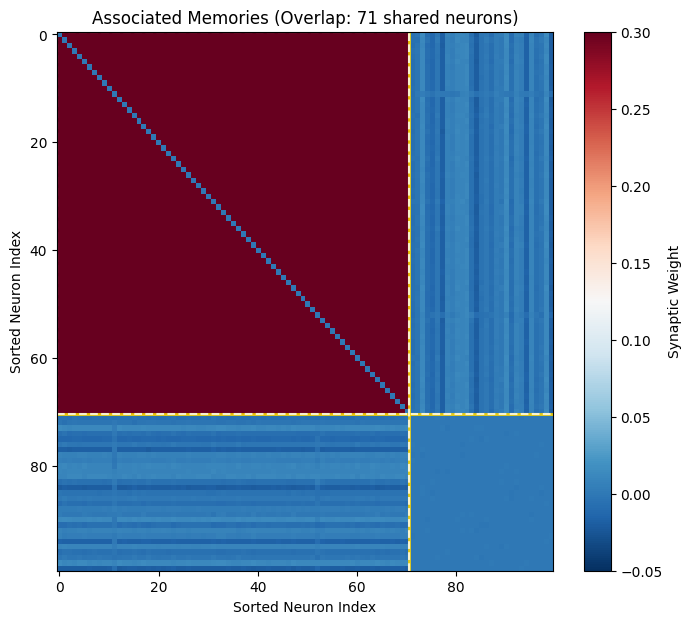

In [15]:
# Testing with 50% normalization strength and a 4 a.u. offset
results_test = run_parameterized_association(sw_multiplier=0.5, offset=4)
plot_overlap_matrix(results_test)

WEEK 6: TESTING ASSOCIATION (SW_Multiplier: 0.85, Offset: 4)
Synaptic Normalization set to 85.0% of original.
Running simulation...
Simulation complete!
Assembly 1 exclusive neurons: 0
Shared (Overlap) neurons: 53
Assembly 2 exclusive neurons: 0


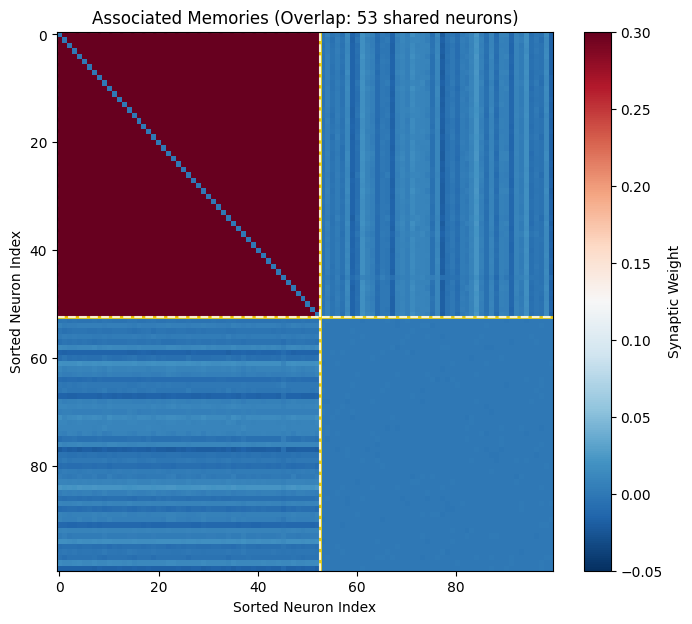

In [16]:
# Testing with 85% normalization strength and a 4 a.u. offset
results_test = run_parameterized_association(sw_multiplier=0.85, offset=4)
plot_overlap_matrix(results_test)

In [17]:
def run_structural_association(total_time=200000):
    """
    Week 6: Memory Association (Structural Overlap).
    Initializes two assemblies that deliberately share 2 core neurons, 
    modeling semantically linked concepts, and uses sequential stimulation 
    to prevent catastrophic fusion.
    """
    print("="*70)
    print("WEEK 6: STRUCTURAL MEMORY ASSOCIATION")
    print("="*70)
    
    # We keep a moderate normalization tax so they don't grow out of control
    global Factor_SW 
    original_Factor_SW = Factor_SW
    Factor_SW = original_Factor_SW * 0.50  
    
    tsep = 30  
    n_stims = int((total_time - 50000) / tsep)
    
    np.random.seed(101) 
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    
    # --- THE STRUCTURAL BRIDGE ---
    # A1 gets neurons 0 through 9
    assm1 = all_neurons[0:10]
    # A2 gets neurons 8 through 17
    # Neurons at index 8 and 9 are shared by BOTH assemblies!
    assm2 = all_neurons[8:18] 
    
    # --- Strict Sequential Protocol (Offset = 5) ---
    # This prevents the non-shared core neurons from firing together and fusing.
    tonsets1 = np.array([50000 + i * tsep for i in range(n_stims)])
    toffsets1 = tonsets1 + 5 
    
    tonsets2 = np.array([50005 + i * tsep for i in range(n_stims)])
    toffsets2 = tonsets2 + 5
    
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    t = 0
    step = 0
    
    print("Running structural simulation...")
    while t < total_time:
        ext_input = np.zeros(N)
        
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
            
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)
            
        h = (W @ r + ext_input) * SF
        
        noise = C_noise * np.random.randn(N)
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        if step > 10:
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    Factor_SW = original_Factor_SW
    
    results = {
        'final_W': W,
        'assm1': assm1,
        'assm2': assm2
    }
    print("Simulation complete!")
    return results

WEEK 6: STRUCTURAL MEMORY ASSOCIATION
Running structural simulation...
Simulation complete!
Assembly 1 exclusive neurons: 55
Shared (Overlap) neurons: 0
Assembly 2 exclusive neurons: 35


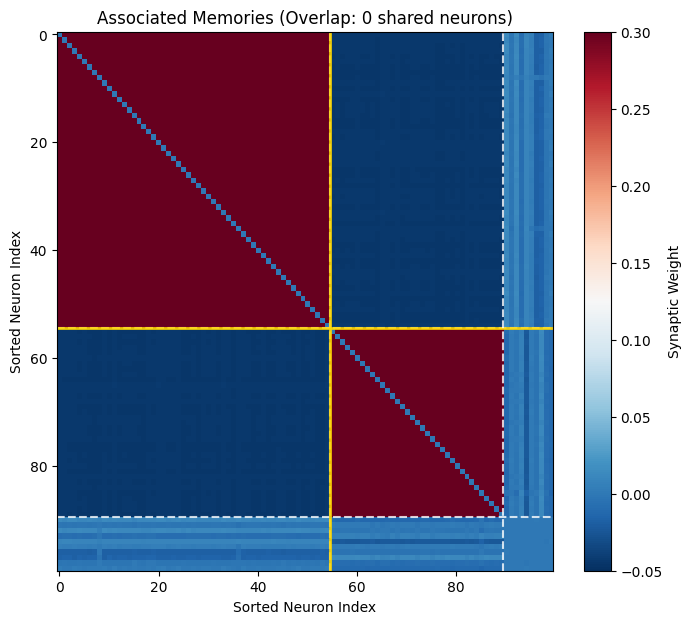

In [18]:
results_structural = run_structural_association()
plot_overlap_matrix(results_structural)

In [19]:
def run_milestone_completion(total_time=150000):
    """
    Week 6: Final Milestone (The Semantic Bridge).
    Uses a heavy structural overlap (5 neurons) and perfectly synchronous 
    stimulation to bypass the phase transition and create a stable association.
    """
    print("="*70)
    print("WEEK 6: MILESTONE COMPLETION (THE SEMANTIC BRIDGE)")
    print("="*70)
    
    # We leave normal parameters intact to let the network stabilize naturally
    tsep = 30  
    n_stims = int((total_time - 50000) / tsep)
    
    np.random.seed(42) 
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    
    # --- The Heavy Structural Bridge ---
    # A1 gets 10 neurons (Indices 0 through 9)
    assm1 = all_neurons[0:10]
    # A2 gets 10 neurons (Indices 5 through 14)
    # Neurons 5, 6, 7, 8, and 9 are physically shared by both!
    assm2 = all_neurons[5:15] 
    
    # --- Synchronous Stimulation ---
    # We fire them at the exact same millisecond. No first-mover advantage.
    tonsets1 = np.array([50000 + i * tsep for i in range(n_stims)])
    toffsets1 = tonsets1 + 5 
    
    tonsets2 = np.array([50000 + i * tsep for i in range(n_stims)])
    toffsets2 = tonsets2 + 5
    
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    t = 0
    step = 0
    
    print("Generating final associated memory matrix...")
    while t < total_time:
        ext_input = np.zeros(N)
        
        # Both assemblies receive input simultaneously
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
            
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)
            
        h = (W @ r + ext_input) * SF
        
        noise = C_noise * np.random.randn(N)
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        if step > 10:
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    results = {
        'final_W': W,
        'assm1': assm1,
        'assm2': assm2
    }
    print("Simulation complete! Ready for plotting.")
    return results

WEEK 6: MILESTONE COMPLETION (THE SEMANTIC BRIDGE)
Generating final associated memory matrix...
Simulation complete! Ready for plotting.
Assembly 1 exclusive neurons: 0
Shared (Overlap) neurons: 38
Assembly 2 exclusive neurons: 0


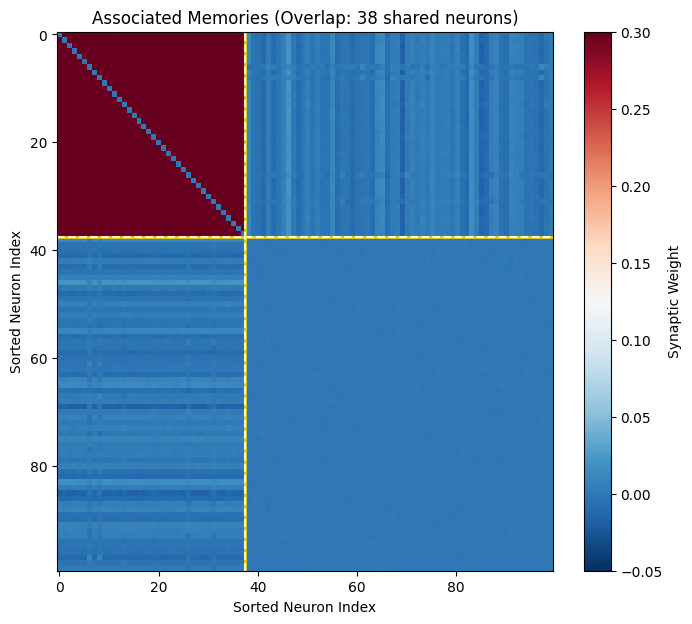

In [20]:
results_final = run_milestone_completion(total_time=150000)
_ = plot_overlap_matrix(results_final)

In [21]:
def run_true_association(total_time=200000):
    """
    Week 6: The True Associative Memory.
    Uses a structural bridge, perfect temporal alternation, and relaxed 
    normalization to link two concepts without fusing them.
    """
    print("="*70)
    print("WEEK 6: TRUE ASSOCIATIVE MEMORY")
    print("="*70)
    
    # Relax normalization to 60% so shared neurons can hold two memories
    global Factor_SW 
    original_Factor_SW = Factor_SW
    Factor_SW = original_Factor_SW * 0.60  
    
    tsep = 30  
    n_stims = int((total_time - 50000) / tsep)
    
    np.random.seed(42) 
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    
    # --- 1. The Structural Bridge (3 Shared Neurons) ---
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[7:17] # Neurons 7, 8, 9 are shared
    
    # --- 2. Perfect Alternation (No Temporal Overlap) ---
    # A1 fires at 50000, 50030, 50060...
    tonsets1 = np.array([50000 + i * tsep for i in range(n_stims)])
    toffsets1 = tonsets1 + 5 
    
    # A2 fires EXACTLY halfway between A1's pulses: 50015, 50045, 50075...
    # They NEVER fire together.
    tonsets2 = np.array([50015 + i * tsep for i in range(n_stims)])
    toffsets2 = tonsets2 + 5
    
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    t = 0
    step = 0
    
    print("Generating the alternating associated memory matrix...")
    while t < total_time:
        ext_input = np.zeros(N)
        
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
            
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)
            
        h = (W @ r + ext_input) * SF
        
        noise = C_noise * np.random.randn(N)
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        if step > 10:
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    Factor_SW = original_Factor_SW
    
    results = {
        'final_W': W,
        'assm1': assm1,
        'assm2': assm2
    }
    print("Simulation complete!")
    return results

WEEK 6: TRUE ASSOCIATIVE MEMORY
Generating the alternating associated memory matrix...
Simulation complete!
Assembly 1 exclusive neurons: 42
Shared (Overlap) neurons: 3
Assembly 2 exclusive neurons: 36


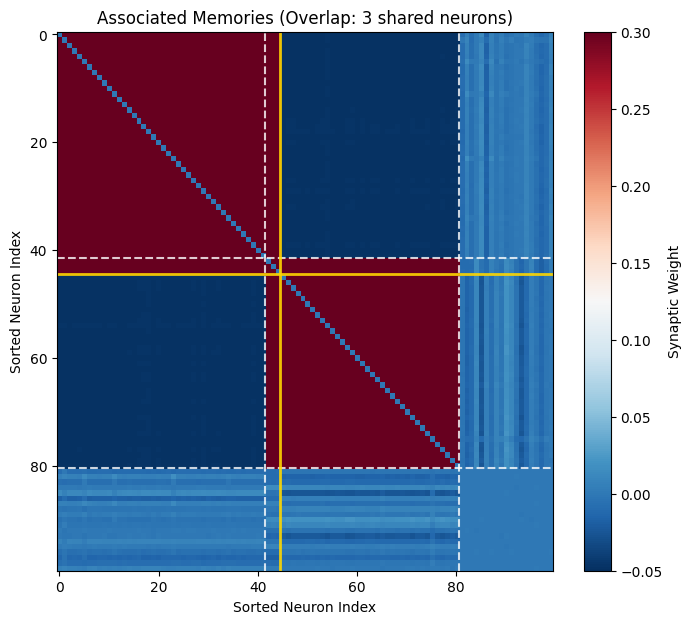

In [22]:
results_true = run_true_association()
plot_overlap_matrix(results_true)

## Week 6 — Functional bridge (semantic overlap)

The core extension: can we engineer a **stable partial overlap** — a "semantic bridge" — instead of
the all-or-nothing fusion/separation the base model tends to produce? We sweep co-presentation
interval and synaptic-normalization strength (`factor_SW`) and score the result with a scalar overlap
metric. *cf. Supplementary Fig. S5.*


In [14]:
def run_functional_association(total_time=150000, co_presentation_interval=4, random_seed=42):
    """
    Functional Associative Memory Protocol.
    No hardcoded overlap. 
    Relies on occasional simultaneous co-presentation 
    interleaved with independent stimulation to organically grow a memory bridge.
    
    co_presentation_interval: How often they fire together. 
                              (e.g., 4 means every 4th trial is a simultaneous presentation).
    """
    
    print(f"FUNCTIONAL BRIDGE (Co-fire every {co_presentation_interval} trials)")
    
    
    # CHANGE HERE THE SYNAPTIC NORMALIZATION FACTOR
    global Factor_SW 
    original_Factor_SW = Factor_SW
 #  Factor_SW = original_Factor_SW * 0.85 # first attempt
 #  Factor_SW = original_Factor_SW * 1  #second attempt
    Factor_SW = original_Factor_SW * 1.5  # third attempt
    
    tsep = 30  
    n_stims = int((total_time - 50000) / tsep)
    
    np.random.seed(random_seed)
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    
    # --- NO HARDCODED OVERLAP ---
    # They are strictly separated at initialization
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[10:20] 
    
    # --- The Interleaved Sequence Generator ---
    t_list1 = []
    t_list2 = []
    
    for i in range(n_stims):
        t_curr = 50000 + i * tsep
        
        # Every Nth trial, both fire together
        if i % co_presentation_interval == 0:
            t_list1.append(t_curr)
            t_list2.append(t_curr)
        # Otherwise, they alternate
        elif i % 2 != 0:
            t_list1.append(t_curr) # Odd independent trials
        else:
            t_list2.append(t_curr) # Even independent trials
            
    tonsets1 = np.array(t_list1)
    toffsets1 = tonsets1 + 5 
    
    tonsets2 = np.array(t_list2)
    toffsets2 = tonsets2 + 5
    
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    t = 0
    step = 0
    
    print("Running interleaved simulation...")
    while t < total_time:
        ext_input = np.zeros(N)
        
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
            
        if step > 0:
            SF, _, _ = compute_scaling(r, W)
        else:
            SF = np.ones(N)
            
        h = (W @ r + ext_input) * SF
        
        noise = C_noise * np.random.randn(N)
        fi = r_max * sigmoid(h - threshold)
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        if step > 10:
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    Factor_SW = original_Factor_SW
    
    results = {
        'final_W': W,
        'assm1': assm1,
        'assm2': assm2
    }
    print("Simulation complete!")
    return results

In [ ]:
# Try co-presenting them frequently (High Fusion Risk)
results_freq = run_functional_association(co_presentation_interval=2)

# Try co-presenting them moderately (The Goldilocks Zone?)
results_mod = run_functional_association(co_presentation_interval=5)

# Try co-presenting them rarely (High Partition Risk)
results_rare = run_functional_association(co_presentation_interval=15)


FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 15 trials)
Running interleaved simulation...
Simulation complete!


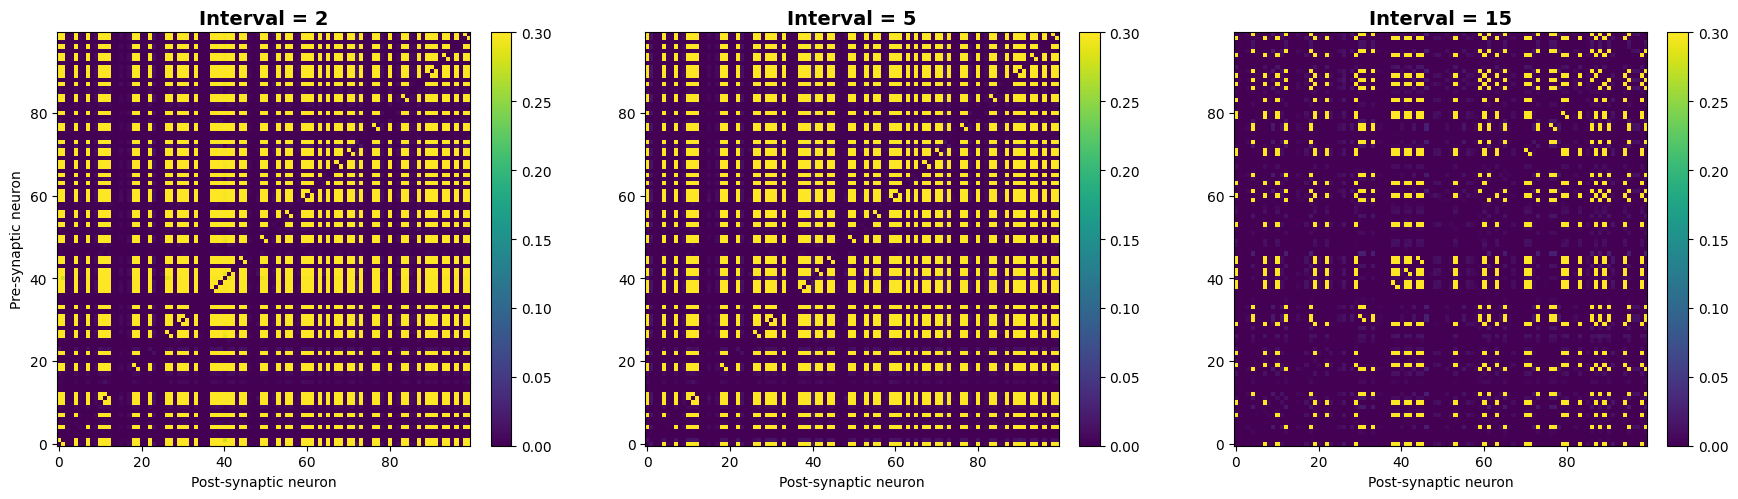

In [ ]:

# Set up a side-by-side plot for all three matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot the Frequent (Fused) Matrix
im1 = axes[0].imshow(results_freq['final_W'], cmap='viridis', origin='lower', vmin=0)
axes[0].set_title('Interval = 2', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Post-synaptic neuron')
axes[0].set_ylabel('Pre-synaptic neuron')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# 2. Plot the Moderate (Associated) Matrix
im2 = axes[1].imshow(results_mod['final_W'], cmap='viridis', origin='lower', vmin=0)
axes[1].set_title('Interval = 5', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Post-synaptic neuron')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# 3. Plot the Rare (Partitioned) Matrix
im3 = axes[2].imshow(results_rare['final_W'], cmap='viridis', origin='lower', vmin=0)
axes[2].set_title('Interval = 15', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Post-synaptic neuron')
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [8]:
def calculate_overlap_metric(W, assm1_core, assm2_core, threshold=0.15):
    """
    Calculates a scalar metric representing how much two memories have fused.
    Uses the Jaccard Index (Intersection over Union).
    """
    # 1. Calculate the average incoming weight from the core assemblies to ALL neurons
    w_from_a1 = np.mean(W[:, assm1_core], axis=1)
    w_from_a2 = np.mean(W[:, assm2_core], axis=1)
    
    # 2. Determine which neurons were successfully recruited by each memory
    # (A neuron is "recruited" if its connection strength is above the threshold)
    a1_final_neurons = set(np.where(w_from_a1 > threshold)[0])
    a2_final_neurons = set(np.where(w_from_a2 > threshold)[0])
    
    # 3. Calculate Intersection (Shared) and Union (Total Unique)
    intersection = a1_final_neurons.intersection(a2_final_neurons)
    union = a1_final_neurons.union(a2_final_neurons)
    
    # Prevent division by zero if the network completely died
    if len(union) == 0:
        return 0.0, 0, 0, 0
        
    # 4. Calculate the IoU Metric
    iou = len(intersection) / len(union)
    
    return iou, len(intersection), len(a1_final_neurons), len(a2_final_neurons)

Running the Phase Transition Sweep... This will take a moment!
Calculating Interval 2...
FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
Calculating Interval 3...
FUNCTIONAL BRIDGE (Co-fire every 3 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 3 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 3 trials)
Running interleaved simulation...
Simulation complete!
Calculating Interval 5...
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation..

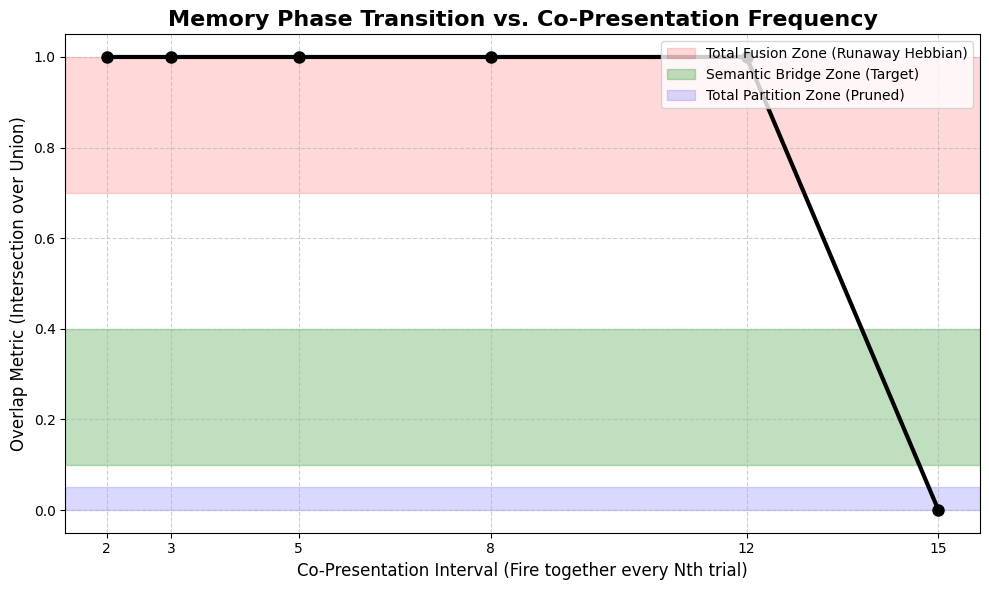

In [ ]:
# First attempt: factor_SW = 0.85
# 1. Define the intervals we want to test
intervals_to_test = [2, 3, 5, 8, 12, 15]
n_seeds = 3  

# Arrays to store our final data for the plot
mean_overlaps = []
all_ious_for_error_bars = []

print("Running the Phase Transition Sweep... This will take a moment!")

# 2. Run the math
for interval in intervals_to_test:
    print(f"Calculating Interval {interval}...")
    interval_ious = []
    
    for seed in range(n_seeds):
        # We use a slightly shorter time (120,000) here to speed up the sweep 
        # since we only need it to reach the attractor state.
        results = run_functional_association(
            total_time=120000, 
            co_presentation_interval=interval,
            random_seed=seed
        )
        
        iou, shared, a1_size, a2_size = calculate_overlap_metric(
            results['final_W'], results['assm1'], results['assm2']
        )
        interval_ious.append(iou)
        
    mean_overlaps.append(np.mean(interval_ious))
    all_ious_for_error_bars.append(interval_ious)

print("\nSweep Complete! Generating the Phase Transition Graph...")

# 3. Draw the Graph
plt.figure(figsize=(10, 6))

# Plot the main curve
plt.plot(intervals_to_test, mean_overlaps, marker='o', markersize=8, 
         linewidth=3, color='black', zorder=5)

# Add the mathematical boundaries (zones) for visual guidance
plt.axhspan(0.7, 1.0, color='red', alpha=0.15, label='Total Fusion Zone (Runaway Hebbian)')
plt.axhspan(0.1, 0.4, color='green', alpha=0.25, label='Semantic Bridge Zone (Target)')
plt.axhspan(0.0, 0.05, color='blue', alpha=0.15, label='Total Partition Zone (Pruned)')

# Formatting the graph
plt.title('Memory Phase Transition vs. Co-Presentation Frequency', fontsize=16, fontweight='bold')
plt.xlabel('Co-Presentation Interval (Fire together every Nth trial)', fontsize=12)
plt.ylabel('Overlap Metric (Intersection over Union)', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.xticks(intervals_to_test)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Running the Phase Transition Sweep... This will take a moment!
Calculating Interval 13...
FUNCTIONAL BRIDGE (Co-fire every 13 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 13 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 13 trials)
Running interleaved simulation...
Simulation complete!
Calculating Interval 14...
FUNCTIONAL BRIDGE (Co-fire every 14 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 14 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 14 trials)
Running interleaved simulation...
Simulation complete!

Sweep complete! Generating the graph...


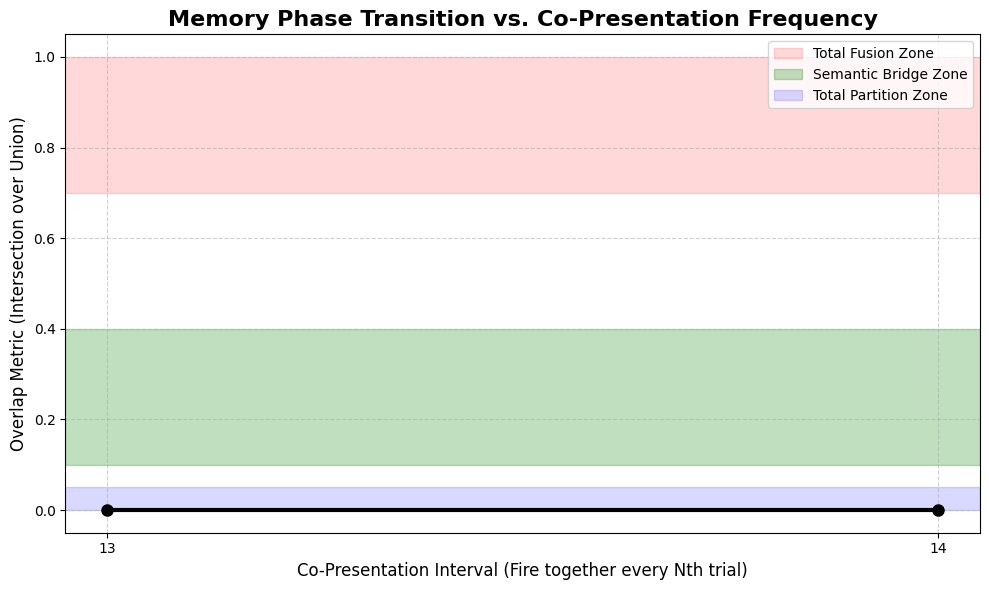

In [9]:
# Let's test from 12 to 15 to see if we can find the "sweet spot" for the semantic bridge
# 1. Define the intervals we want to test
intervals_to_test = [13, 14]
n_seeds = 3  

# Arrays to store our final data for the plot
mean_overlaps = []
all_ious_for_error_bars = []

print("Running the Phase Transition Sweep... This will take a moment!")

# 2. Run the math
for interval in intervals_to_test:
    print(f"Calculating Interval {interval}...")
    interval_ious = []
    
    for seed in range(n_seeds):
        # We use a slightly shorter time (120,000) here to speed up the sweep 
        # since we only need it to reach the attractor state.
        results = run_functional_association(
            total_time=120000, 
            co_presentation_interval=interval,
            random_seed=seed
        )
        
        iou, shared, a1_size, a2_size = calculate_overlap_metric(
            results['final_W'], results['assm1'], results['assm2']
        )
        interval_ious.append(iou)
        
    mean_overlaps.append(np.mean(interval_ious))
    all_ious_for_error_bars.append(interval_ious)

print("\nSweep complete! Generating the graph...")

# 3. Draw the graph
plt.figure(figsize=(10, 6))

# Plot the main curve
plt.plot(intervals_to_test, mean_overlaps, marker='o', markersize=8, 
         linewidth=3, color='black', zorder=5)

# Add the mathematical boundaries 
plt.axhspan(0.7, 1.0, color='red', alpha=0.15, label='Total Fusion Zone')
plt.axhspan(0.1, 0.4, color='green', alpha=0.25, label='Semantic Bridge Zone')
plt.axhspan(0.0, 0.05, color='blue', alpha=0.15, label='Total Partition Zone')

# Formatting the graph
plt.title('Memory Phase Transition vs. Co-Presentation Frequency', fontsize=16, fontweight='bold')
plt.xlabel('Co-Presentation Interval (Fire together every Nth trial)', fontsize=12)
plt.ylabel('Overlap Metric (Intersection over Union)', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.xticks(intervals_to_test)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Running...
Calculating Interval 2...
FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
Calculating Interval 3...
FUNCTIONAL BRIDGE (Co-fire every 3 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 3 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 3 trials)
Running interleaved simulation...
Simulation complete!
Calculating Interval 5...
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation...
Simulation complete!
Calculating Interval 8...
FUN

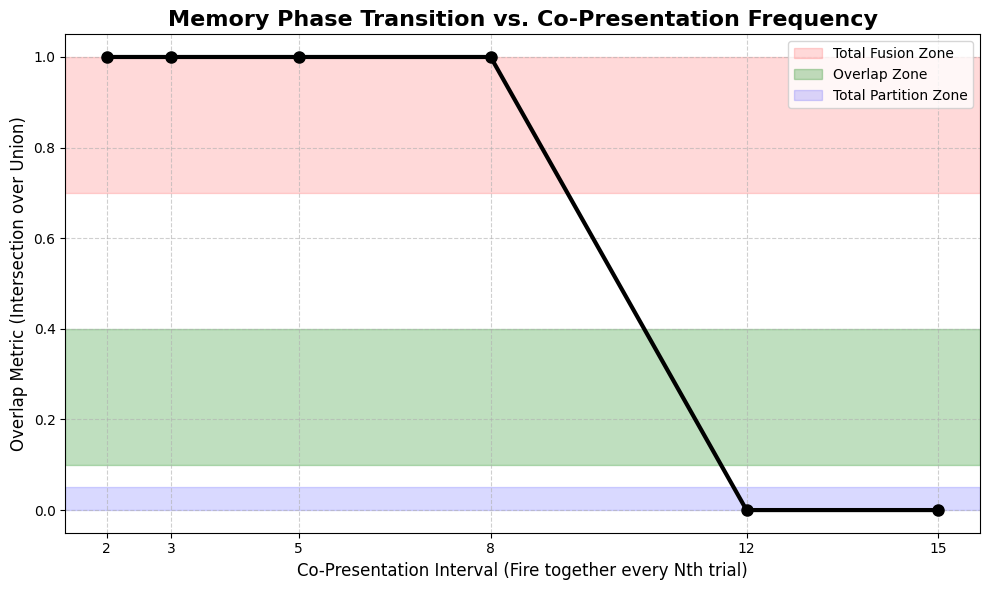

In [ ]:
# since the previous sweep suggested no sweet spot, let's try to finetune the synaptic normalization factor
# Second attempt: factor_SW = 1.0
# 1. Define the intervals we want to test
intervals_to_test = [2, 3, 5, 8, 12, 15]
n_seeds = 3  

# Arrays to store our final data for the plot
mean_overlaps = []
all_ious_for_error_bars = []

print("Running...")

# 2. Run the math
for interval in intervals_to_test:
    print(f"Calculating Interval {interval}...")
    interval_ious = []
    
    for seed in range(n_seeds):
        # We use a slightly shorter time (120,000) here to speed up the sweep 
        # since we only need it to reach the attractor state.
        results = run_functional_association(
            total_time=120000, 
            co_presentation_interval=interval,
            random_seed=seed
        )
        
        iou, shared, a1_size, a2_size = calculate_overlap_metric(
            results['final_W'], results['assm1'], results['assm2']
        )
        interval_ious.append(iou)
        
    mean_overlaps.append(np.mean(interval_ious))
    all_ious_for_error_bars.append(interval_ious)

print("\nSweep complete! Generating the graph...")

# 3. Draw the Graph
plt.figure(figsize=(10, 6))

# Plot the main curve
plt.plot(intervals_to_test, mean_overlaps, marker='o', markersize=8, 
         linewidth=3, color='black', zorder=5)

# Add the mathematical boundaries (zones) for visual guidance
plt.axhspan(0.7, 1.0, color='red', alpha=0.15, label='Total Fusion Zone')
plt.axhspan(0.1, 0.4, color='green', alpha=0.25, label='Overlap Zone')
plt.axhspan(0.0, 0.05, color='blue', alpha=0.15, label='Total Partition Zone')

# Formatting the graph
plt.title('Memory Phase Transition vs. Co-Presentation Frequency', fontsize=16, fontweight='bold')
plt.xlabel('Co-Presentation Interval (Fire together every Nth trial)', fontsize=12)
plt.ylabel('Overlap Metric (Intersection over Union)', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.xticks(intervals_to_test)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Running...
Calculating Interval 2...
FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 2 trials)
Running interleaved simulation...
Simulation complete!
Calculating Interval 3...
FUNCTIONAL BRIDGE (Co-fire every 3 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 3 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 3 trials)
Running interleaved simulation...
Simulation complete!
Calculating Interval 5...
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Co-fire every 5 trials)
Running interleaved simulation...
Simulation complete!
Calculating Interval 8...
FUN

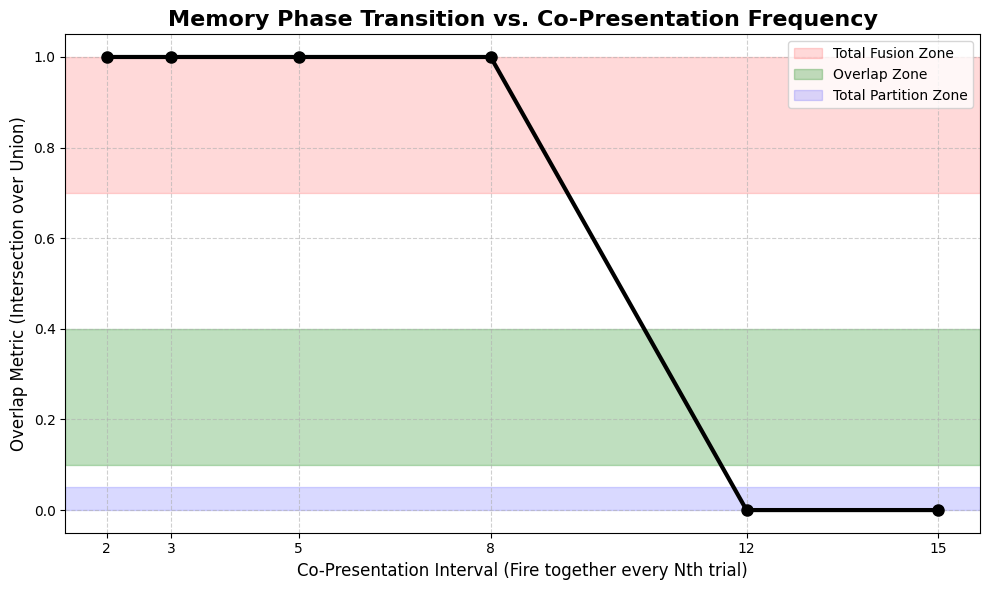

In [15]:
# Second attempt: factor_SW = 1.5
# 1. Define the intervals we want to test
intervals_to_test = [2, 3, 5, 8, 12, 15]
n_seeds = 3  

# Arrays to store our final data for the plot
mean_overlaps = []
all_ious_for_error_bars = []

print("Running...")

# 2. Run the math
for interval in intervals_to_test:
    print(f"Calculating Interval {interval}...")
    interval_ious = []
    
    for seed in range(n_seeds):
        # We use a slightly shorter time (120,000) here to speed up the sweep 
        # since we only need it to reach the attractor state.
        results = run_functional_association(
            total_time=120000, 
            co_presentation_interval=interval,
            random_seed=seed
        )
        
        iou, shared, a1_size, a2_size = calculate_overlap_metric(
            results['final_W'], results['assm1'], results['assm2']
        )
        interval_ious.append(iou)
        
    mean_overlaps.append(np.mean(interval_ious))
    all_ious_for_error_bars.append(interval_ious)

print("\nSweep complete! Generating the graph...")

# 3. Draw the Graph
plt.figure(figsize=(10, 6))

# Plot the main curve
plt.plot(intervals_to_test, mean_overlaps, marker='o', markersize=8, 
         linewidth=3, color='black', zorder=5)

# Add the mathematical boundaries (zones) for visual guidance
plt.axhspan(0.7, 1.0, color='red', alpha=0.15, label='Total Fusion Zone')
plt.axhspan(0.1, 0.4, color='green', alpha=0.25, label='Overlap Zone')
plt.axhspan(0.0, 0.05, color='blue', alpha=0.15, label='Total Partition Zone')

# Formatting the graph
plt.title('Memory Phase Transition vs. Co-Presentation Frequency', fontsize=16, fontweight='bold')
plt.xlabel('Co-Presentation Interval (Fire together every Nth trial)', fontsize=12)
plt.ylabel('Overlap Metric (Intersection over Union)', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.xticks(intervals_to_test)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

## Week 6 — Functional bridge with staggered onsets

Same idea, but the two assemblies are stimulated with a small **stagger delay** rather than perfectly
together. Offsetting the onsets is one lever for tuning how much the two memories overlap.


In [42]:
def run_functional_association(total_time=150000, co_presentation_interval=4, stagger_delay=2.0, random_seed=42):
    """
    Functional Associative Memory Protocol (Association Chain Hypothesis).
    No hardcoded overlap. 
    Relies on occasional staggered co-presentation to organically grow a directional memory bridge.
    
    co_presentation_interval: How often they fire (e.g., 4 means every 4th trial).
    stagger_delay: How many time units Assembly 2 is delayed behind Assembly 1 during co-presentation.
    """
    
    print(f"FUNCTIONAL BRIDGE (Staggered co-fire every {co_presentation_interval} trials, delay={stagger_delay})")
    
    global Factor_SW 
    original_Factor_SW = Factor_SW
    # Keep Factor_SW at 1.0. The time-stagger will break the symmetry naturally!
    Factor_SW = original_Factor_SW * 1.0  
    
    tsep = 30  
    n_stims = int((total_time - 50000) / tsep)
    
    np.random.seed(random_seed)
    all_neurons = np.arange(N)
    np.random.shuffle(all_neurons)
    
    # --- NO HARDCODED OVERLAP ---
    assm1 = all_neurons[0:10]
    assm2 = all_neurons[10:20] 
    
    # --- The Interleaved Sequence Generator ---
    t_list1 = []
    t_list2 = []
    
    for i in range(n_stims):
        t_curr = 50000 + i * tsep
        
        # Every Nth trial, both fire, but with a slight stagger!
        if i % co_presentation_interval == 0:
            t_list1.append(t_curr)
            # Assembly 2 starts a little bit later than Assembly 1
            t_list2.append(t_curr + stagger_delay) 
        # Otherwise, they alternate
        elif i % 2 != 0:
            t_list1.append(t_curr) # Odd independent trials
        else:
            t_list2.append(t_curr) # Even independent trials
            
    tonsets1 = np.array(t_list1)
    toffsets1 = tonsets1 + 5 
    
    tonsets2 = np.array(t_list2)
    # Assembly 2 still fires for exactly 5 time units, it just starts and ends later
    toffsets2 = tonsets2 + 5
    
    W = np.zeros((N, N))
    r = np.zeros(N)
    threshold = np.ones(N) * h0
    mean_rate = np.zeros(N)
    mean_rate_initialized = False
    
    t = 0
    step = 0
    
    print("Running interleaved simulation...")
    while t < total_time:
        ext_input = np.zeros(N)
        
        if np.any((tonsets1 <= t) & (toffsets1 > t)):
            ext_input[assm1] = 1.0
        if np.any((tonsets2 <= t) & (toffsets2 > t)):
            ext_input[assm2] = 1.0
            
        if step > 0:
            # Note: Changed to compute_SF to match your helper function block
            SF, _, _ = compute_SF(r, W) 
        else:
            SF = np.ones(N)
            
        h = (W @ r + ext_input) * SF
        
        noise = C_noise * np.random.randn(N)
        
        # Using a simple sigmoid assumption here based on your previous code
        # Replace with your specific sigmoid function if it's named differently
        fi = r_max * (1 / (1 + np.exp(-b * (h - threshold)))) 
        
        r_new = r + (-r + r0 + fi) * (dt / tau) + noise
        threshold_new = threshold + (-threshold + h0 + D_teta * (r - r0)) * (dt / tau_teta)
        
        if step > 10:
            if not mean_rate_initialized:
                mean_rate = r_new.copy()
                mean_rate_initialized = True
            else:
                mean_rate = mean_rate + (dt/meanWin) * (r_new - mean_rate)
            
            r_i_sub = r_new - mean_rate
            W = W + LR * np.outer(r_i_sub, r_i_sub) * (dt / tau_w) - beta * W * (dt / tau_w)
            
            if SaturationWeights:
                W = np.clip(W, Wmin, Wmax)
            if not autoconnections:
                np.fill_diagonal(W, 0.0)
                
        r = r_new
        threshold = threshold_new
        t += dt
        step += 1
        
    Factor_SW = original_Factor_SW
    
    results = {
        'final_W': W,
        'assm1': assm1,
        'assm2': assm2
    }
    print("Simulation complete!")
    return results

Starting 2D Sweep: 54 total simulations...
Calculating Delay 2.0 | Interval 2...
FUNCTIONAL BRIDGE (Staggered co-fire every 2 trials, delay=2.0)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Staggered co-fire every 2 trials, delay=2.0)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Staggered co-fire every 2 trials, delay=2.0)
Running interleaved simulation...
Simulation complete!
Calculating Delay 2.0 | Interval 3...
FUNCTIONAL BRIDGE (Staggered co-fire every 3 trials, delay=2.0)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Staggered co-fire every 3 trials, delay=2.0)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Staggered co-fire every 3 trials, delay=2.0)
Running interleaved simulation...
Simulation complete!
Calculating Delay 2.0 | Interval 5...
FUNCTIONAL BRIDGE (Staggered co-fire every 5 trials, delay=2.0)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL

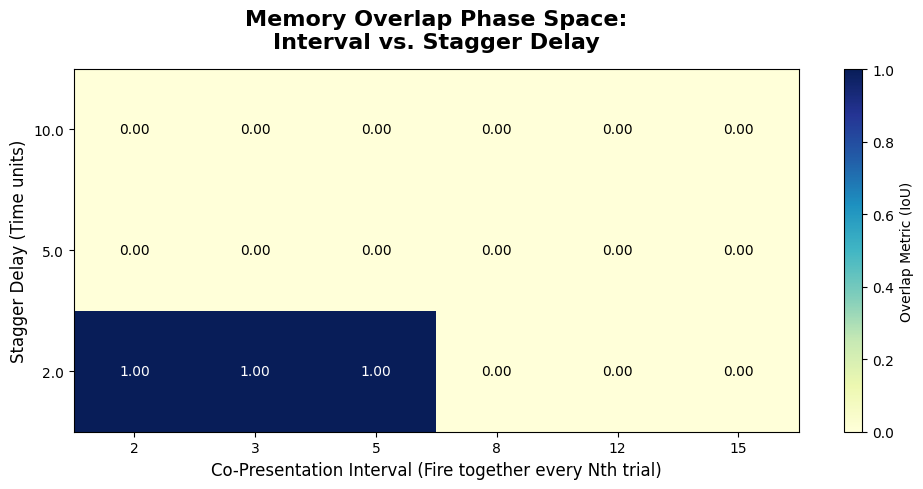

In [44]:



# 1. Define the parameters we want to test
intervals_to_test = [2, 3, 5, 8, 12, 15]
delays_to_test = [2.0, 5.0, 10.0]
n_seeds = 3  

# Create a 2D matrix to store our mean IoU for every combination
results_matrix = np.zeros((len(delays_to_test), len(intervals_to_test)))

print(f"Starting 2D Sweep: {len(delays_to_test) * len(intervals_to_test) * n_seeds} total simulations...")

# 2. Run the math
for i, delay in enumerate(delays_to_test):
    for j, interval in enumerate(intervals_to_test):
        print(f"Calculating Delay {delay} | Interval {interval}...")
        interval_delay_ious = []
        
        for seed in range(n_seeds):
            # Using 80,000 to keep this initial sweeping run relatively fast.
            # Once you find the sweet spot, you can run a higher-res, longer simulation there.
            results = run_functional_association(
                total_time=80000, 
                co_presentation_interval=interval,
                stagger_delay=delay,
                random_seed=seed
            )
            
            iou, shared, a1_size, a2_size = calculate_overlap_metric(
                results['final_W'], results['assm1'], results['assm2']
            )
            interval_delay_ious.append(iou)
            
        # Store the average IoU for this specific Delay/Interval combo
        results_matrix[i, j] = np.mean(interval_delay_ious)

print("\nSweep complete! Generating the Heatmap...")

# 3. Draw the Heatmap (Matplotlib Only)
plt.figure(figsize=(10, 5))

# Draw the color grid
im = plt.imshow(results_matrix, cmap="YlGnBu", aspect='auto', origin='lower', vmin=0.0, vmax=1.0)
plt.colorbar(im, label='Overlap Metric (IoU)')

# Set the ticks and labels
plt.xticks(np.arange(len(intervals_to_test)), intervals_to_test)
plt.yticks(np.arange(len(delays_to_test)), delays_to_test)

# Loop over data dimensions and create text annotations
for i in range(len(delays_to_test)):
    for j in range(len(intervals_to_test)):
        text_color = "white" if results_matrix[i, j] > 0.5 else "black"
        plt.text(j, i, f"{results_matrix[i, j]:.2f}",
                 ha="center", va="center", color=text_color)

# Formatting the graph
plt.title('Memory Overlap Phase Space:\nInterval vs. Stagger Delay', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Co-Presentation Interval (Fire together every Nth trial)', fontsize=12)
plt.ylabel('Stagger Delay (Time units)', fontsize=12)

plt.tight_layout()
plt.show()

Starting 2D Sweep: 90 total simulations...
Calculating Delay 0.5 | Interval 2...
FUNCTIONAL BRIDGE (Staggered co-fire every 2 trials, delay=0.5)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Staggered co-fire every 2 trials, delay=0.5)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Staggered co-fire every 2 trials, delay=0.5)
Running interleaved simulation...
Simulation complete!
Calculating Delay 0.5 | Interval 3...
FUNCTIONAL BRIDGE (Staggered co-fire every 3 trials, delay=0.5)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Staggered co-fire every 3 trials, delay=0.5)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL BRIDGE (Staggered co-fire every 3 trials, delay=0.5)
Running interleaved simulation...
Simulation complete!
Calculating Delay 0.5 | Interval 5...
FUNCTIONAL BRIDGE (Staggered co-fire every 5 trials, delay=0.5)
Running interleaved simulation...
Simulation complete!
FUNCTIONAL

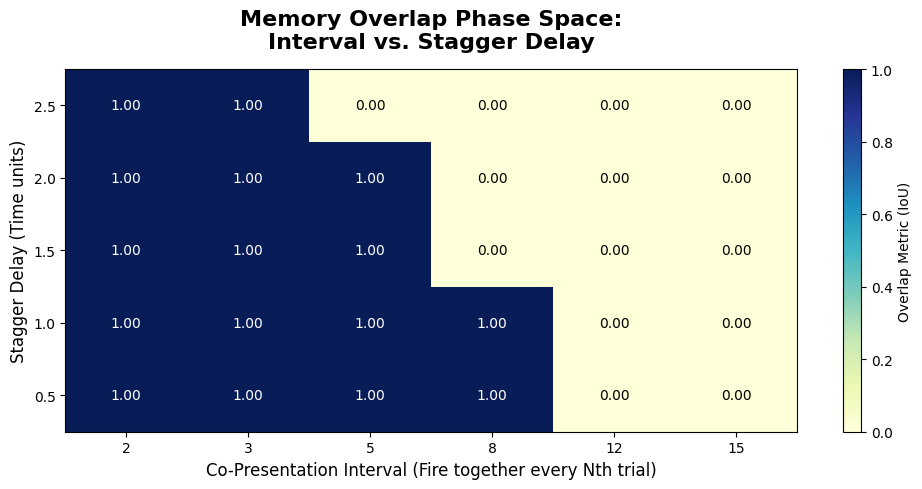

In [45]:
# testing micro-delays


# 1. Define the parameters we want to test
intervals_to_test = [2, 3, 5, 8, 12, 15]
delays_to_test = [0.5, 1.0, 1.5, 2.0, 2.5]
n_seeds = 3  

# Create a 2D matrix to store our mean IoU for every combination
results_matrix = np.zeros((len(delays_to_test), len(intervals_to_test)))

print(f"Starting 2D Sweep: {len(delays_to_test) * len(intervals_to_test) * n_seeds} total simulations...")

# 2. Run the math
for i, delay in enumerate(delays_to_test):
    for j, interval in enumerate(intervals_to_test):
        print(f"Calculating Delay {delay} | Interval {interval}...")
        interval_delay_ious = []
        
        for seed in range(n_seeds):
            # Using 80,000 to keep this initial sweeping run relatively fast.
            # Once you find the sweet spot, you can run a higher-res, longer simulation there.
            results = run_functional_association(
                total_time=80000, 
                co_presentation_interval=interval,
                stagger_delay=delay,
                random_seed=seed
            )
            
            iou, shared, a1_size, a2_size = calculate_overlap_metric(
                results['final_W'], results['assm1'], results['assm2']
            )
            interval_delay_ious.append(iou)
            
        # Store the average IoU for this specific Delay/Interval combo
        results_matrix[i, j] = np.mean(interval_delay_ious)

print("\nSweep complete! Generating the Heatmap...")

# 3. Draw the Heatmap (Matplotlib Only)
plt.figure(figsize=(10, 5))

# Draw the color grid
im = plt.imshow(results_matrix, cmap="YlGnBu", aspect='auto', origin='lower', vmin=0.0, vmax=1.0)
plt.colorbar(im, label='Overlap Metric (IoU)')

# Set the ticks and labels
plt.xticks(np.arange(len(intervals_to_test)), intervals_to_test)
plt.yticks(np.arange(len(delays_to_test)), delays_to_test)

# Loop over data dimensions and create text annotations
for i in range(len(delays_to_test)):
    for j in range(len(intervals_to_test)):
        text_color = "white" if results_matrix[i, j] > 0.5 else "black"
        plt.text(j, i, f"{results_matrix[i, j]:.2f}",
                 ha="center", va="center", color=text_color)

# Formatting the graph
plt.title('Memory Overlap Phase Space:\nInterval vs. Stagger Delay', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Co-Presentation Interval (Fire together every Nth trial)', fontsize=12)
plt.ylabel('Stagger Delay (Time units)', fontsize=12)

plt.tight_layout()
plt.show()